## Analyzing Customer Satisfaction from Yelp Reviews (2005-2022)

### Situation
In the competitive, market-oriented business landscape, understanding customer satisfaction is critical for companies to thrive. The rise of online platforms like Yelp has generated vast amounts of user-generated review data, offering valuable insights into customer needs and preferences. Businesses face the challenge of analyzing this unstructured text data to identify key drivers of satisfaction and adapt to evolving customer expectations. 

### Task
Provide actionable insights for businesses to enhance customer satisfaction, loyalty, and profitability using Yelp reviews from 2005 to 2022 across 19 U.S. states. Download the data from this link https://business.yelp.com/data/resources/open-dataset/ and choose the 4.35GB TAR file. 

I set out to answer the following questions: 
- What are the most frequently occurring words in Yelp customer reviews across states and across the different business categories?
- Are there differences in Yelp reviews based on the state where the business is located?
- Demonstrate how to investigate reviews for a particular phrase or particular keyword using a 'dictionary'.

### Action
To address the research questions, the following actions were taken using the Cross-Industry Standard Process for Data Mining (CRISP-DM) methodology. 

<img width="391" alt="Screenshot 2025-06-02 at 2 36 13 AM" src="https://github.com/user-attachments/assets/c9c78813-4466-4741-9401-2f12874b43b4" />

**Data Understanding:** Collected two JSON files (118.9 MB and 180.6 MB) from Yelp’s dataset, containing business details and customer reviews. These were merged using business identification keys, resulting in a dataset of 6,990,280 rows with 22 variables. Due to processing constraints, a 1.45% stratefied sample was used for this project due to processing constraints.

**Data Preparation:**
- Built a **corpus** (a corpus is a collection of text documents, like gathering all Yelp reviews into one big set for analysis)
- **converted the corpus to lowercase** (made all letters lowercase so "Great" and "great" count as the same word) 
- **removed punctuation** (like commas, periods, and exclamation points), **removed whitespace in the reviews** (extra spaces or blank lines)
- **removed stop words** (common words like "the," "and," "is" that don’t add much meaning), and 
- **applied stemming/lemmatization** (simplified words, e.g., stemming turns "running" to "run" lemmatization turns "better" to "good"; this is important to group similar words and reduce the number of unique words to analyze) to reduce data size (makes the data smaller and easier to process).

- **Tokenize the corpus** (A spreadsheet where rows are reviews, columns are words, and cells show how often each word appears; it’s important because it lets us count and compare words like "food" or "service" across reviews to find what customers care about most).

**Analysis**
- **Frequent Words:** Used term frequency (TF) and term frequency-inverse document frequency (TF-IDF) to identify high-frequency words. 

- **Frequent Phrases:** Tokenized reviews into bigrams, trigrams removed stop words, and analyzed phrase frequency using TF-IDF across states and business categories to see what customers think across states and across business categories.

- **Inspect the corpus for particular words:** Constructed a dictionary with words from Giese and Cote’s customer satisfaction model (“quality,” “value,” “expect,” “complain,” “loyalty,” “service,” “satisfy”) and analyzed their frequency in reviews using term frequency (TF) and term frequency-inverse document frequency (TF-IDF).


### Result
The analysis yielded the following key findings:

**Frequent Words:** The top 10 high-frequency words across Yelp reviews were “food,” “service,” “love,” “amazing,” “delicious,” “awesome,” “time,” “friendly,” “nice,” and “staff,” indicating a focus on food quality and service experience.

**Frequent Phrases:** Top bigrams included “mountain dining,”, “awesome atmosphere,” and “fresh food”, "great service quality", "staff super friendly" with notable prevalence in states like Connecticut, South Dakota, and New Jersey.

**State-Based Differences:** While common words like “food” and “service” appeared across all states, some states showed unique preferences across various business categories.

**Giese and Cote Model:** Words from the model were prevalent in reviews, with “service” appearing in 85% of reviews, “quality” in 8.5%, “expect” in 3.7%, “value” in 1.7%, “satisfied” in 0.5%, and “loyalty” and “complain” in 0.4% each, confirming the model’s relevance.

**Business Impact:**
- The findings underscored the universal importance of service and food quality, consistent with Giese and Cote’s model and expectancy disconfirmation theory.

- Recommendations included prioritizing prompt service, friendly staff, high food quality, quick service and a conducive atmosphere. Businesses are advised to leverage marketing focused on service quality, offer personalized experiences, and incentivize reviews with rewards like gift cards.

- The study highlighted text mining’s role in extracting actionable insights, giving businesses a competitive edge in understanding customer needs.

**Limitations:**
- Uneven review distribution across states limited generalizability.
- Lack of keyword context analysis may obscure nuanced meanings.

In [2]:
import pandas as pd
import json

def load_clean_jsonl(file_path):
    """
    Loads a JSON Lines (.json) file safely, skipping malformed lines.
    Returns a pandas DataFrame.
    """
    records = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, start=1):
            try:
                record = json.loads(line)
                records.append(record)
            except json.JSONDecodeError:
                print(f" Skipped malformed line {line_num}")
                continue
    return pd.DataFrame(records)

# Load the business metadata
business_df = load_clean_jsonl("yelp_academic_dataset_business.json")

# Load the review text data
text_df = load_clean_jsonl("yelp_academic_dataset_review.json")

# Optional: Display summary
print(f"Loaded {len(business_df)} business entries")
print(f"Loaded {len(text_df)} reviews")

# Optional: Save to CSV for inspection
# business_df.to_csv("cleaned_business_data.csv", index=False)
# text_df.to_csv("cleaned_text_data.csv", index=False)

# Merge the business and review data on 'business_id'
customer_reviews = pd.merge(business_df, text_df, on="business_id")
customer_reviews.head()

✅ Loaded 150346 business entries
✅ Loaded 6990280 reviews


,business_id,name,address,city,state,postal_code,latitude,longitude,stars_x,review_count,...,categories,hours,review_id,user_id,stars_y,useful,funny,cool,text,date
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,"Doctors, Traditional Chinese Medicine, Naturop...",None,9vwYDBVI3ymdqcyJ5WW2Tg,e0imecnX_9MtLnS2rUZM-A,5.0,3,2,1,I've had acupuncture treatments with Abby over...,2012-05-02 18:07:38
1,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,"Doctors, Traditional Chinese Medicine, Naturop...",None,OXgg1LdxHDv3CBU5-xi2lA,_Q0fdLVoTnlNkEypUvNkHA,5.0,1,0,0,Abby is an amazing practitioner. In a treatmen...,2013-03-01 06:11:05
2,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,"Doctors, Traditional Chinese Medicine, Naturop...",None,DG64cjud9cWB4fANskVxSw,ycUooVIDWPgXPf6niW-FWQ,4.0,2,0,0,I went to see Abby for some digestive issues. ...,2013-01-17 00:05:43
3,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,"Doctors, Traditional Chinese Medicine, Naturop...",None,hzvRRb40oPttxAdyr7kfow,CiwVvb7jWijWB5jkmatzKA,5.0,0,1,0,"Abby helped me with some longstanding issues, ...",2015-03-16 03:43:08
4,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,...,"Doctors, Traditional Chinese Medicine, Naturop...",None,xUkBPk-QfcW4i3MRU5TeXw,QkCbMKBktkrkOFJugHvY6w,5.0,0,0,0,"Recently, I referred a patient of mine with mu...",2013-03-05 18:45:07


In [196]:
customer_reviews.isnull().sum() 
# customer_reviews.to_csv("Cust_Reviews.csv", index=False) # You can save the imported data at this point

### Observation: 
The imported dataset contains 6,990,280 rows with 22 columns. Given the large nature of the data and lack of computational power to process it, we will work with a stratified 1.45% sample of the data for this project, which is 101,358 rows across 22 columns. The number of reviews collected are uneven across states. Customer reviews were collected across 19 states and across 46594 businesses from 2005 to 2022. Reviews from these states -PA, FL, TN, LA, IN -represent 29% of the total number of reviews collected. 

In [210]:
import pandas as pd

# Set the percentage of rows to keep
keep_percent = 0.0145

# Calculate number of rows to keep
num_rows = int(len(customer_reviews) * keep_percent)

# Select a random subset of rows without replacement
subset = customer_reviews.sample(n=num_rows, replace=False, random_state=42)  # random_state for reproducibility

# Save the subset
subset.to_csv("yelp_reviews.csv", index=False)

NameError: name 'customer_reviews' is not defined

In [211]:
# Import the stratified sampled data 
df=pd.read_csv("yelp_reviews.csv")
df.head()

,business_id,name,address,city,state,postal_code,latitude,longitude,stars_x,review_count,...,categories,hours,review_id,user_id,stars_y,useful,funny,cool,text,date
0,bRAVdxf2JLXSPVT6xFNhTw,Eva's Pancake House & Restaurants,2654 Lake Circle Dr,Indianapolis,IN,46268,39.912932,-86.206339,3.5,25,...,"Fish & Chips, Breakfast & Brunch, Restaurants,...","{'Monday': '7:0-15:0', 'Tuesday': '7:0-15:0', ...",SvgqqgpmPF7CCmugSf_Kzg,dITOyDnz14HB7bx0S2WCZw,5.0,0,0,0,Lots of choices on the menu. I had a delicious...,2018-03-10 19:34:40
1,Ps7Q7BOKzJO4nDTUhbk43Q,Clear Sky Cafe,"490 Mandalay Ave, Ste 1",Clearwater,FL,33767,27.981960,-82.827297,4.5,1824,...,"Restaurants, American (Traditional), Tapas/Sma...","{'Monday': '7:0-23:0', 'Tuesday': '7:0-23:0', ...",sHgzHgw-LUBfDOSsEbnK-w,Zb9Cm0EKJf3w_iRnrOcAtA,5.0,0,0,0,"Ashley M. Was PHENOMENAL! Met every, extremely...",2019-06-28 16:45:15
2,4bS9BqDL0zUNxS8EJKYROw,Cairo Cakes,25 S Main St,Yardley,PA,19067,40.241936,-74.838245,4.5,38,...,"Bakeries, Food","{'Tuesday': '9:0-19:0', 'Wednesday': '9:0-19:0...",5G7OyHPhFI6XlgnSUQ99fg,sNQPihGPv-JpC5yAN8CzXA,1.0,0,1,0,I am very disappointed to say that I was not h...,2017-11-09 15:35:20
3,434A83c2ig6QxsZjrjclpQ,Las Margaritas,2538 Welsh Rd,Philadelphia,PA,19152,40.072607,-75.034125,3.5,511,...,"Restaurants, Mexican, Nightlife, Bars","{'Monday': '11:0-22:0', 'Tuesday': '11:0-22:0'...",a3jbxbYpoM90LCZ1aZaMpA,6cjXa37M_QFvrkdqWnmEGg,5.0,1,0,0,This is one of the best places in that area. A...,2014-01-08 02:14:41
4,xwjUyOwIQuFNaBCxhedwLA,Edley's Bar-B-Que,908 Main St,Nashville,TN,37206,36.176127,-86.756714,4.0,731,...,"Bars, Restaurants, Nightlife, Barbeque, Cockta...","{'Monday': '11:0-21:0', 'Tuesday': '11:0-21:0'...",qMXlIfgWM_ZXos8gGBLXbw,dG8SK7tMdwfboSGc3bDyZQ,5.0,0,0,0,Amazing Ribs with a nice smokey flavor. Can't ...,2016-03-29 16:25:31


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101359 entries, 0 to 101358
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   101359 non-null  object 
 1   name          101359 non-null  object 
 2   address       100173 non-null  object 
 3   city          101359 non-null  object 
 4   state         101359 non-null  object 
 5   postal_code   101349 non-null  object 
 6   latitude      101359 non-null  float64
 7   longitude     101359 non-null  float64
 8   stars_x       101359 non-null  float64
 9   review_count  101359 non-null  int64  
 10  is_open       101359 non-null  int64  
 11  attributes    98695 non-null   object 
 12  categories    101348 non-null  object 
 13  hours         95578 non-null   object 
 14  review_id     101359 non-null  object 
 15  user_id       101359 non-null  object 
 16  stars_y       101359 non-null  float64
 17  useful        101359 non-null  int64  
 18  funn

In [213]:
# look at range of a variable 
print("Dataset shape:", df.shape)
# df.shape - using print("verbiage", df.shape) will output more than one result. if you don't, pytho outputs 
# only the last command

print("max date is:", df['date'].max())
print("max date is:", df['date'].min())

# Count 
print("There are:", df['state'].nunique(), "states in this dataset") #distinct() would not work now

# Reviews were collected from 2005 to 2022 across 18 states

Dataset shape: (101359, 22)
max date is: 2022-01-19 18:52:58
max date is: 2005-03-16 04:26:19
There are: 19 states in this dataset


In [173]:
# Range of dates
date_range = df['date'].min(), df['date'].max()
min_year = df['year'].min()
max_year = df['year'].max()
print(f"\n{df['business_id'].nunique()} businesses were reviewed from {min_year} to {max_year}")


46594 businesses were reviewed from 2005 to 2022


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101359 entries, 0 to 101358
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   101359 non-null  object 
 1   name          101359 non-null  object 
 2   address       100173 non-null  object 
 3   city          101359 non-null  object 
 4   state         101359 non-null  object 
 5   postal_code   101349 non-null  object 
 6   latitude      101359 non-null  float64
 7   longitude     101359 non-null  float64
 8   stars_x       101359 non-null  float64
 9   review_count  101359 non-null  int64  
 10  is_open       101359 non-null  int64  
 11  attributes    98695 non-null   object 
 12  categories    101348 non-null  object 
 13  hours         95578 non-null   object 
 14  review_id     101359 non-null  object 
 15  user_id       101359 non-null  object 
 16  stars_y       101359 non-null  float64
 17  useful        101359 non-null  int64  
 18  funn

In [215]:
# Convert 'date' variable to 'datetime' and extract year 
df['date'] = pd.to_datetime(df['date'], errors='coerce') 
df['year'] = df['date'].dt.year

In [216]:
# --- Analysis 1: Group by state and count number of unique businesses --- 
my_summary = (df.groupby('state')
              .agg(num_businesses=('business_id', 'nunique')) # aggregrate by unique business_id (great way to count)
              .reset_index()
              .sort_values('num_businesses', ascending=False)) # list result in descending order 
my_summary.head(3)

# Print summary data
print("Number of Businesses per State:", my_summary)

Number of Businesses per State:    state  num_businesses
14    PA           10685
5     FL            7898
16    TN            3905
10    LA            3540
9     IN            3501
11    MO            3471
1     AZ            3065
13    NV            2666
12    NJ            2331
2     CA            1932
7     ID            1247
0     AB            1197
4     DE             631
8     IL             519
6     HI               2
15    SD               1
3     CO               1
17    TX               1
18    UT               1


#### Observation
The above shows the number of businesses reviewed per state. This is consistent with the original dataset where PA had many more reviews than the other states.

In [217]:
# --- Analysis 2: Count the number of reviews per state, sorted by count ---
state_review_counts = (df.groupby('state')
                      .agg(num_reviews=('review_id', 'count'))
                      .reset_index()
                      .sort_values('num_reviews', ascending=False))

# Print review counts
print("\nNumber of Reviews per State (Sorted):", state_review_counts)


Number of Reviews per State (Sorted):    state  num_reviews
14    PA        23098
5     FL        16710
10    LA        11059
16    TN         8858
11    MO         7353
9     IN         7157
13    NV         6226
1     AZ         6189
2     CA         5070
12    NJ         3930
7     ID         2248
0     AB         1622
4     DE         1039
8     IL          794
6     HI            2
15    SD            1
3     CO            1
17    TX            1
18    UT            1


In [218]:
# --- Analysis 3: Count the number of reviews per year, sorted by count ---
year_review_counts = (df.groupby('year')
                     .agg(num_reviews=('review_id', 'count'))
                     .reset_index()
                     .sort_values('num_reviews', ascending=False))

# Print year review counts
print("\nNumber of Reviews per Year (Sorted):", year_review_counts)


Number of Reviews per Year (Sorted):     year  num_reviews
14  2019        13241
13  2018        13047
12  2017        11958
11  2016        10970
10  2015        10017
16  2021         8974
15  2020         7928
9   2014         7564
8   2013         5596
7   2012         4147
6   2011         3382
5   2010         2022
4   2009         1078
3   2008          681
17  2022          454
2   2007          232
1   2006           53
0   2005           15


In [219]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

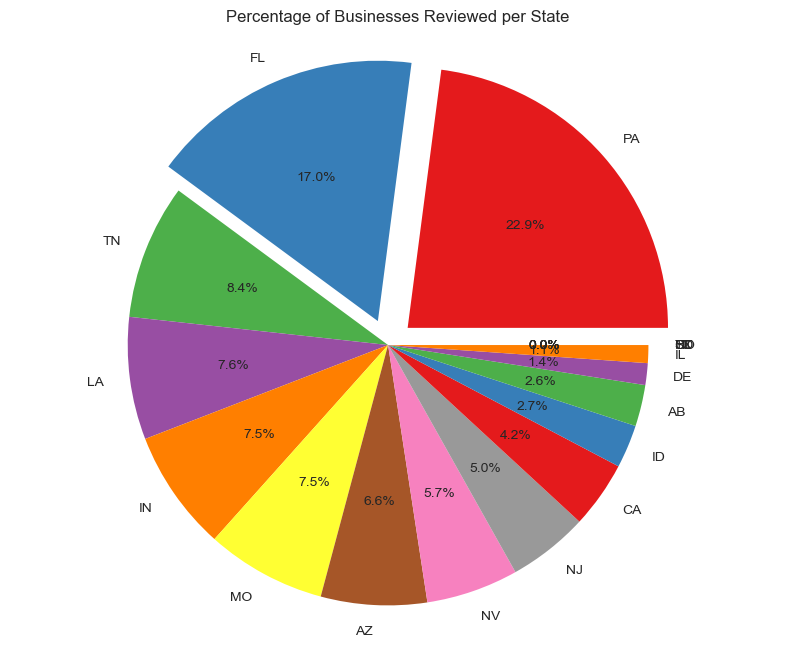

In [220]:
# Set the seaborn style for consistent visualization
plt.style.use('seaborn')

# Calculate the total number of businesses
total_businesses = my_summary['num_businesses'].sum()

# Calculate the percentage of businesses per state
my_summary['percentage_businesses'] = (my_summary['num_businesses'] / total_businesses * 100).round(2)

# Plot pie chart

# Fallback to static matplotlib pie chart with vibrant Set1 palette
plt.figure(figsize=(10, 8), dpi=100)  # Increased resolution for clarity
plt.pie(my_summary['percentage_businesses'], 
            labels=my_summary['state'], 
            autopct='%1.1f%%', 
            colors=sns.color_palette('Set1', len(my_summary)),  # Vibrant Set1 palette
            explode=[0.1 if p > 10 else 0 for p in my_summary['percentage_businesses']])
plt.title('Percentage of Businesses Reviewed per State')
plt.axis('equal')  # Equal aspect ratio ensures pie chart is circular
plt.show()

### Observation:
This pie chart displays the percentage of businesses reviewed in each state, calculated as (number of businesses in state / total businesses) * 100, rounded to 2 decimal places. For business leaders, 

1) This visualization highlights market concentration: Larger slices (e.g., Pensylvania, California, Arizona) indicate competitive markets where differentiation through superior service or quality is critical. 

2) Smaller slices suggest untapped markets or areas with fewer reviews, offering opportunities to potentially expand presence or encourage customer feedback through incentives (e.g., gift cards)

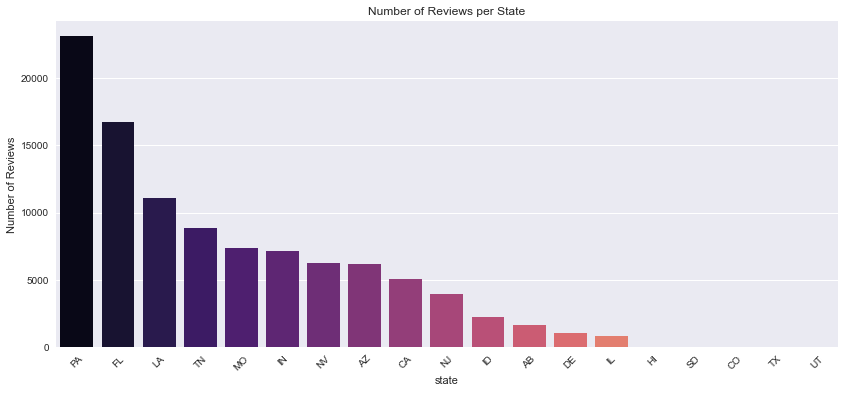

In [221]:
# 2. Plot number of reviews per state
plt.figure(figsize=(14, 6))
sns.barplot(x='state', y='num_reviews', data=state_review_counts, palette='magma')
plt.title('Number of Reviews per State')
plt.xticks(rotation=45)
plt.ylabel('Number of Reviews')
plt.show()

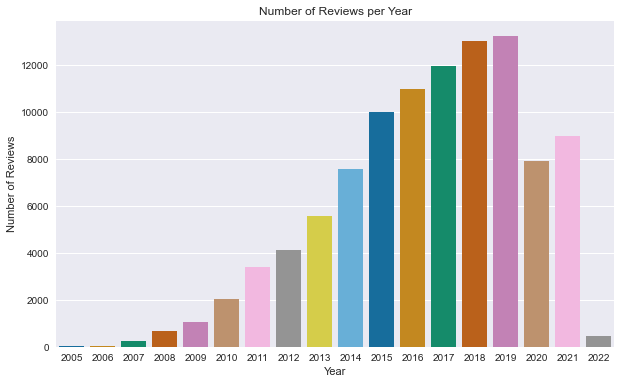

In [223]:
# 3. Plot number of reviews per year
plt.figure(figsize=(10, 6))
sns.barplot(x='year', y='num_reviews', data=year_review_counts, palette='colorblind')
plt.title('Number of Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

#### Observation 
1) We observe a steady rising volumes of reviews from 2005 to 2019.  Post-2015, we see an even heightened customer interest, presenting opportunities to capitalize on this momentum with enhanced service quality, marketing campaigns, or loyalty programs to retain and attract customers. 

2) A drop or stagnation in recent years (e.g., 2020-2022) could signal external factors like the pandemic impact.

3) Implement review-incentive programs (e.g., discounts, gift cards) to boost engagement.


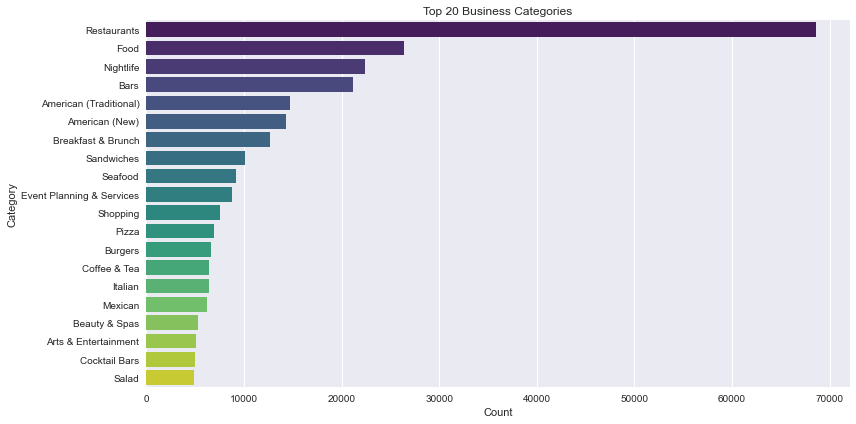

In [159]:
# What category of businesses were reviewed in this data set? 
from collections import Counter

category_series = df['categories'].dropna().str.split(', ')
flat_categories = [item for sublist in category_series for item in sublist]
top_categories = Counter(flat_categories).most_common(20)
cat_df = pd.DataFrame(top_categories, columns=['Category', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=cat_df, x='Count', y='Category', palette='viridis')
plt.title('Top 20 Business Categories')
plt.tight_layout()
plt.show()

**Observations:**

The following categories Restaurants, Nightlife, Bars, Traditional American, New American, Breakfast & Brunch represent a significant part of the reviews collected.

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

We rename the variables 'stars_x' and 'stars_y' to 'business_stars' and 'user_stars' respectively for clarity.

In [228]:
# Rename columns for clarity (stars_x = business rating, stars_y = user rating)
df.rename(columns=
          {'stars_x': 'business_stars', 'stars_y': 'user_stars'}, inplace=True)

In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101359 entries, 0 to 101358
Data columns (total 24 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   business_id     101359 non-null  object        
 1   name            101359 non-null  object        
 2   address         100173 non-null  object        
 3   city            101359 non-null  object        
 4   state           101359 non-null  object        
 5   postal_code     101349 non-null  object        
 6   latitude        101359 non-null  float64       
 7   longitude       101359 non-null  float64       
 8   business_stars  101359 non-null  float64       
 9   review_count    101359 non-null  int64         
 10  is_open         101359 non-null  bool          
 11  attributes      98695 non-null   object        
 12  categories      101348 non-null  object        
 13  hours           95578 non-null   object        
 14  review_id       101359 non-null  obj

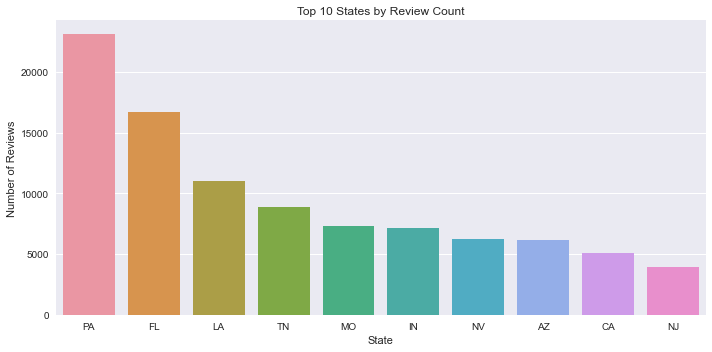

In [230]:
# --- Univariate Analysis ---
# Top states by number of reviews
top_states = df['state'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title('Top 10 States by Review Count')
plt.ylabel('Number of Reviews')
plt.xlabel('State')
plt.tight_layout()
plt.show()

#### Observation: 
These are the top 10 states by reviews
1) Pennsylvania (PA) leads with the highest number of reviews, surpassing 22,000.

2) Florida (FL) follows with around 17,000 reviews.

3) Louisiana (LA), Tennessee (TN), and Missouri (MO) are next.

In [231]:
# creating state_metrics from the loaded DataFrame called df
state_metrics = df.groupby('state').agg( # group states by # of reviews and average ratings of the business
    num_reviews=('review_count', 'count'), 
    avg_stars=('business_stars', 'mean')
).reset_index()

state_metrics

,state,num_reviews,avg_stars
0,AB,1622,3.569975
1,AZ,6189,3.701729
2,CA,5070,3.972584
3,CO,1,4.000000
4,DE,1039,3.540905
5,FL,16710,3.777768
6,HI,2,4.250000
7,ID,2248,3.779137
8,IL,794,3.525819
9,IN,7157,3.792092


In [232]:
# Convert 'is_open' variable from data type 'int64' to boolean (assuming '0 = closed', '1 = open')
df['is_open'] = df['is_open'].astype(bool)

Extract the 'year' from the variable 'date' for further analysis

In [233]:
# 3. Look at the average user ratings (0 to 5) from 2005 to 2022
df['year'] = df['date'].dt.year
yearly_trends = df.groupby('year')['user_stars'].agg(['mean', 'count']).reset_index()
print("Yearly trends by average user ratings\n", yearly_trends)

Yearly trends by average user ratings
     year      mean  count
0   2005  3.733333     15
1   2006  3.924528     53
2   2007  3.875000    232
3   2008  3.756241    681
4   2009  3.732839   1078
5   2010  3.703264   2022
6   2011  3.665287   3382
7   2012  3.676875   4147
8   2013  3.698892   5596
9   2014  3.725542   7564
10  2015  3.733253  10017
11  2016  3.764813  10970
12  2017  3.771116  11958
13  2018  3.756572  13047
14  2019  3.761121  13241
15  2020  3.798184   7928
16  2021  3.717963   8974
17  2022  3.704846    454


---
#### Length of reviews versus user stars with 1 (worst) to 5 (best)
---

Now, we explore the length of reviews versus user ratings. We start by creating a variable "review_length" and then another  variable length_vs_stars where the comparison is done. We observa the following:

1) Negative reviews (1–2 stars) often include detailed complaints or explanations of what went wrong. Users tend to vent frustrations and justify their low ratings. Reason why they're long. 

2) Positive reviews (especially 5 stars) are often short and to the point — quick praise like “Great service!” or “Loved it!” doesn’t require much elaboration.

The longer the review, the lower the stars as suggests the correlation coefficient but the correlation coefficient 
is not strong, only 19%. Thus, there isn't enough statistical evidence.

In [234]:
# 4. Explore the length of reviews versus user ratings
df['review_length'] = df['text'].str.len()
length_vs_stars = df.groupby('user_stars')['review_length'].mean().reset_index()
length_vs_stars

,user_stars,review_length
0,1.0,711.161113
1,2.0,722.451576
2,3.0,670.833449
3,4.0,583.510171
4,5.0,461.865633


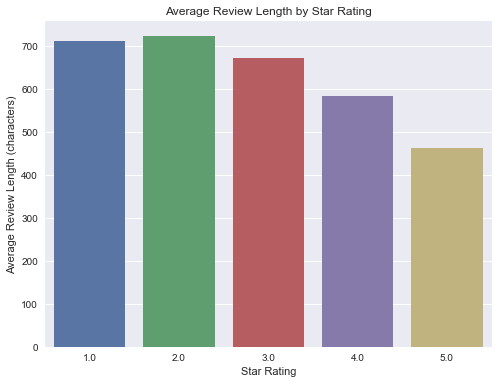

In [235]:
# 5. Review Length vs Stars
plt.figure(figsize=(8, 6))
sns.barplot(x='user_stars', y='review_length', data=length_vs_stars)
plt.title('Average Review Length by Star Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Review Length (characters)')
plt.show()

In [236]:
# --- Insights --- 
print("Top 5 States by Number of Reviews:") 
print(state_metrics.sort_values('num_reviews', ascending=False)[['state', 'num_reviews']].head())
print("\nTop 5 States by Average Review Stars:")
print(state_metrics.sort_values('avg_stars', ascending=False)[['state', 'avg_stars']].head())
print("\nCorrelation between Number of Reviews and Average Stars:")
print(state_metrics['num_reviews'].corr(state_metrics['avg_stars']))
print("\nCorrelation between Review Length and Stars:")
print(df['review_length'].corr(df['user_stars']))

Top 5 States by Number of Reviews:
   state  num_reviews
14    PA        23098
5     FL        16710
10    LA        11059
16    TN         8858
11    MO         7353

Top 5 States by Average Review Stars:
   state  avg_stars
18    UT   4.500000
15    SD   4.500000
6     HI   4.250000
3     CO   4.000000
2     CA   3.972584

Correlation between Number of Reviews and Average Stars:
0.0416221612075175

Correlation between Review Length and Stars:
-0.19235654412329908


---
#### What type of business categories were reviewed by customers across states?
---

In [241]:
# Example of Top Categories for a few states and this category is by the number of reviews
print("\nTop 3 Categories for Top 5 States by Reviews:")
top_review_states = state_metrics.sort_values('num_reviews', ascending=False)['state'].head(5)
for state in top_review_states:
    print(f"\n{state}:")
    print(top_categories[top_categories['state'] == state][['categories', 'count']])


Top 3 Categories for Top 5 States by Reviews:

PA:
              categories  count
63    Pizza, Restaurants    170
64  Mexican, Restaurants    160
65  Restaurants, Italian    159
66    Restaurants, Pizza    129
67  Restaurants, Mexican    119

FL:
              categories  count
21  Mexican, Restaurants    130
22    Pizza, Restaurants     88
23  Restaurants, Mexican     88
24    Restaurants, Pizza     77
25  Italian, Restaurants     73

LA:
                                           categories  count
43                 Cajun/Creole, Seafood, Restaurants    123
44  Live/Raw Food, Seafood, Restaurants, Cajun/Creole    122
45  Restaurants, Seafood, Cajun/Creole, Breakfast ...    116
46  Cajun/Creole, Restaurants, Event Planning & Se...     78
47                               Seafood, Restaurants     77

TN:
                                           categories  count
69  American (Traditional), Chicken Shop, Southern...     95
70                               Restaurants, Mexican     72


In [239]:
# Example: Generate top_categories with top 5 categories per state
top_categories = (
    df.explode('categories') 
      .groupby(['state', 'categories'])
      .size()
      .reset_index(name='count')
      .groupby('state')
      .apply(lambda x: x.nlargest(5, 'count'))
      .reset_index(drop=True)
)
top_categories

,state,categories,count
0,AB,"Vietnamese, Restaurants",16
1,AB,"Burgers, Restaurants",13
2,AB,"Coffee & Tea, Food",13
3,AB,"Restaurants, Chinese",12
4,AB,"Restaurants, Vietnamese",12
...,...,...,...
71,TN,"Mexican, Restaurants",69
72,TN,"Burgers, American (Traditional), Breakfast & B...",68
73,TN,"Burgers, Sandwiches, Food, Beer, Wine & Spirit...",46
74,TX,"Real Estate, Home Services, Apartments",1


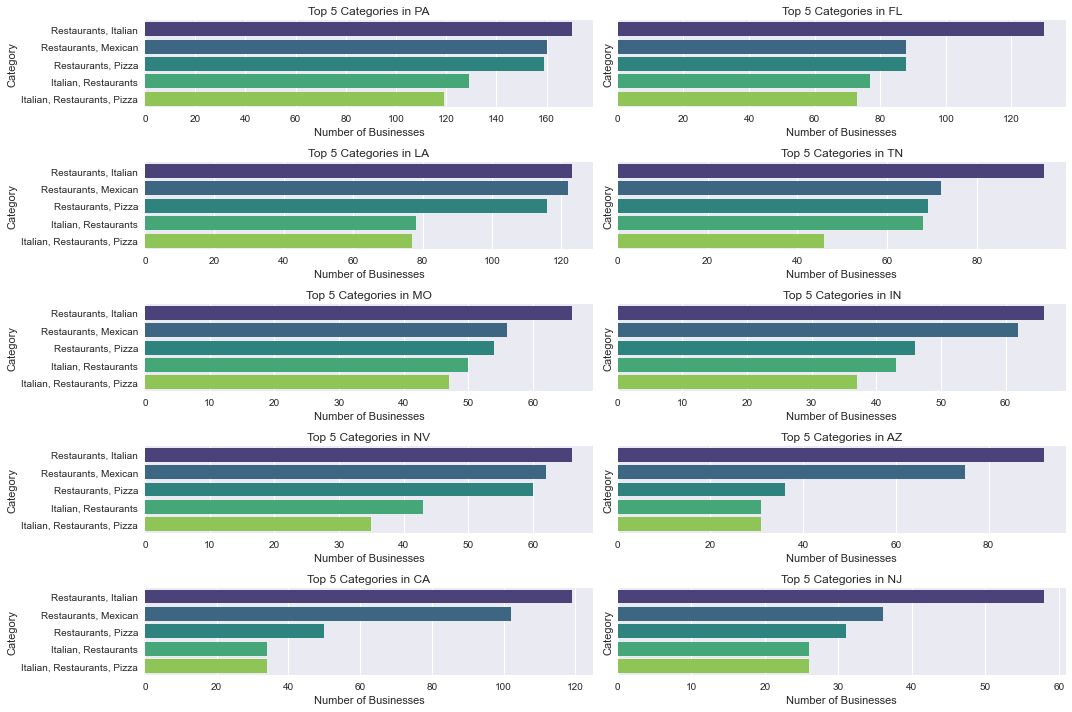

In [242]:
# Get the top 10 states by number of reviews
top_review_states = state_metrics.sort_values('num_reviews', ascending=False)['state'].head(10)

# Set plot style
plt.style.use('seaborn')

# Create a figure with subplots for each state
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(15, 10), sharey=True)
axes = axes.flatten()  # Flatten for easier iteration

# Plot top 5 categories for each of the top 10 states
for idx, state in enumerate(top_review_states):
    # select top 5 categories instead of all
    state_data = (top_categories[top_categories['state'] == state]
                  .nlargest(5, 'count')[['categories', 'count']]) 

    sns.barplot(x='count', y='categories', data=state_data, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'Top 5 Categories in {state}') 
    axes[idx].set_xlabel('Number of Businesses')
    axes[idx].set_ylabel('Category')

# Remove the extra subplot
if len(top_review_states) < len(axes):
    fig.delaxes(axes[-1])

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

---
#### Let's dive into analyzing reviews and dig even deeper to see what customers are saying across states
---

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import bigrams
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from collections import Counter

In [52]:
# Download required atural language packages for data analysis
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/apple/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/apple/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [245]:
# --- Text Length Analysis ---
df['text_length'] = df['text'].str.len()
print("\nAverage Review Length (characters) is:", df['text_length'].mean())


Average Review Length (characters) is: 566.7518917905662


---
#### Preparing reviews for analysis
---
**1. Remove stop words** and **tokenization**

Words such as 'the', 'is', 'and' etc., are considered to have little meaningful content on their own and thus referred to as 'stopwords'. There are about 179 words built into that dictionary in python. Removing stopwords prepares to filter out noise from reviews, focusing analysis on substantive customer feedback.

Tokenization breaks down review text into individual words (tokens), converts them to lowercase for consistency,
and filters out non-alphanumeric characters (e.g., punctuation, numbers). The result is a list of meaningful tokens.

In [248]:
# --- Text Preprocessing and Tokenization ---

# Step 1: Define a set of English stop words
stop_words = set(stopwords.words('english'))


# Step 2: Define a function to tokenize and clean text
def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [word for word in tokens if word.isalnum() and word not in stop_words] #alnum()  alphanumeric 


# Step 3: Apply the tokenization function to the review text column
df['tokens'] = df['text'].apply(tokenize_text)

# This applies the tokenize_text() to each review in the 'text' column of the DataFrame, creating a new 'tokens' column
# with processed word lists for every review. It transforms raw text into a structured format for further analysis.

# Step 4: Flatten tokens and compute word frequency
all_tokens = [token for tokens in df['tokens'] for token in tokens]
word_freq = Counter(all_tokens)

# This step flattens the nested token lists into a single list and uses Counter to count the occurrence of each word across all reviews,
# producing a frequency dictionary (word_freq). It quantifies which words are most prevalent in customer feedback.

---
#### Most Frequent Words in customer reviews (Term Frequency) refers to what is generally said by customers
---

 We look at this for the entire corpus and visualize words that occur >= 1,380 times.


Top 20 Most Frequent Words:
       word  count
0      food  52288
1      good  47626
2     place  46264
3     great  44449
4   service  33110
5      time  32268
6     would  31922
7      like  31480
8       one  30791
9       get  30624
10     back  29596
11       go  25239
12   really  23726
13     also  21742
14      got  20202
15       us  19811
16    could  18072
17     even  18028
18     nice  17856
19     best  17561


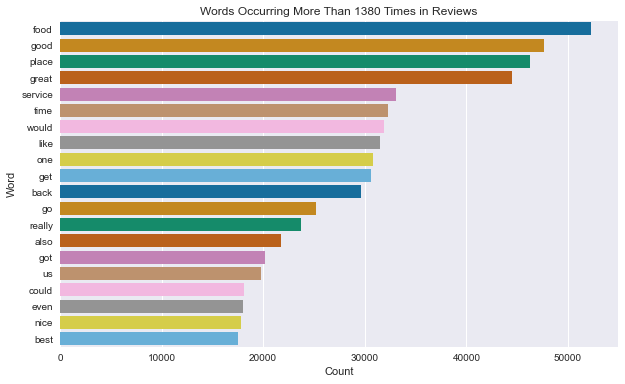

In [250]:
# Top words overall
top_words = pd.DataFrame(word_freq.most_common(20), columns=['word', 'count'])
print("\nTop 20 Most Frequent Words:")
print(top_words)

# Visualize words occurring more than a threshold (e.g., 1380)
threshold = 1380
plt.figure(figsize=(10, 6))
top_words_filtered = top_words[top_words['count'] > threshold]
sns.barplot(x='count', y='word', data=top_words_filtered, palette='colorblind')
plt.title('Words Occurring More Than 1380 Times in Reviews')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

---
#### What are customers frequently saying across states?
---
We examine 5 top frequently used words in reviews

<Figure size 1080x720 with 0 Axes>

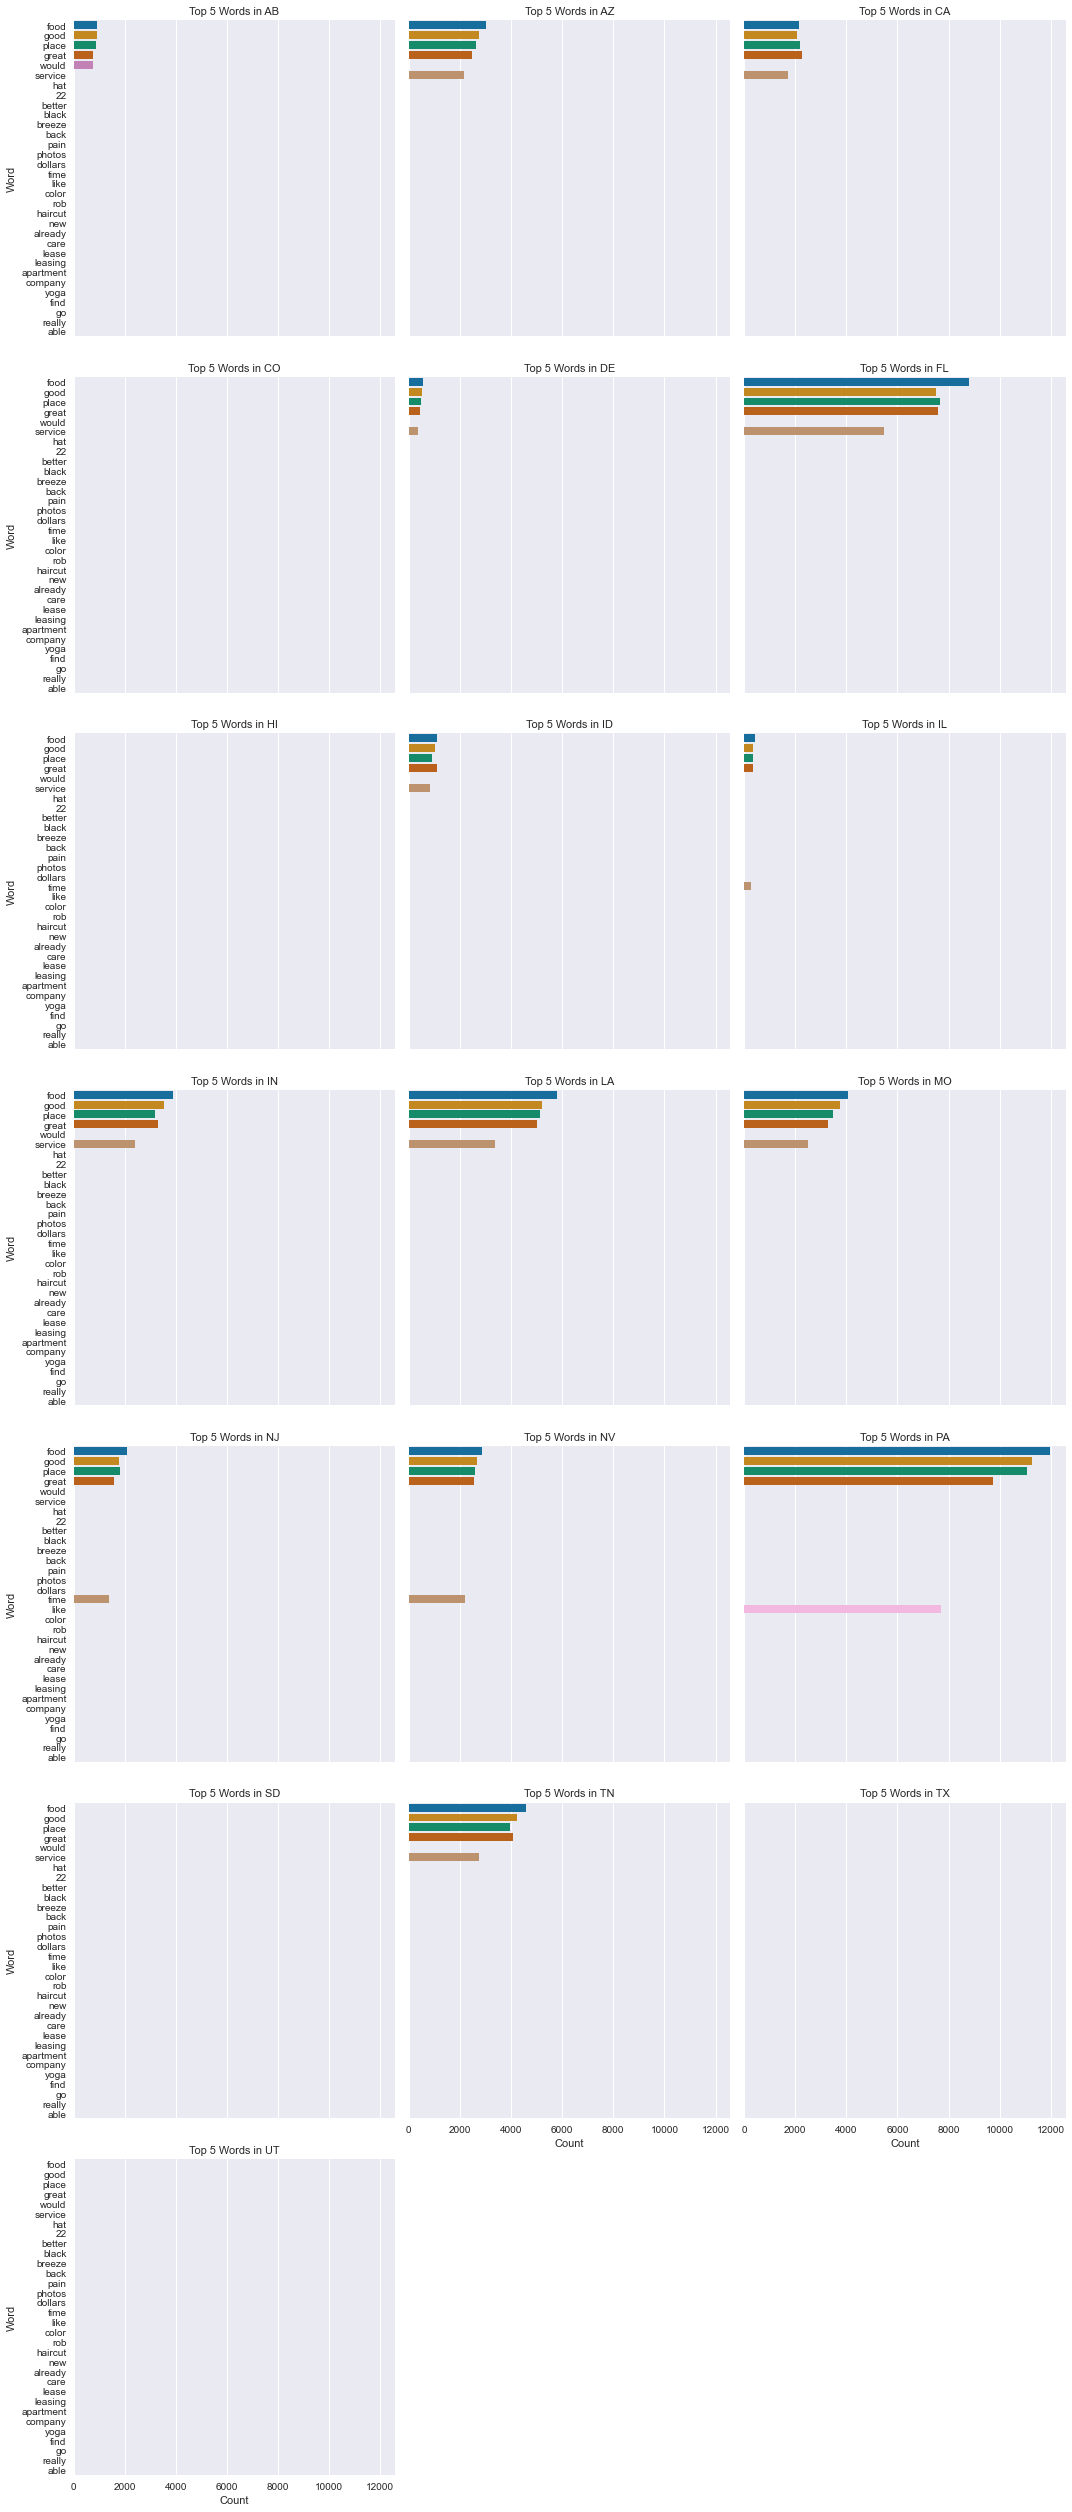

In [252]:
# Step 1: Explode the 'tokens' column so that each word in the list becomes its own row
# This allows counting individual word occurrences per state
word_freq_by_state = (
    df.explode('tokens') 
      .groupby(['state', 'tokens'])  # Group by state and individual word
      .size()  # Count the number of occurrences for each word in each state
      .reset_index(name='count')  # Convert the result to a DataFrame and name the count column
)

# Step 2: For each state, select the top 5 most frequent words
top_words_by_state = (
    word_freq_by_state
      .groupby('state')  # Group the word frequencies by state
      .apply(lambda x: x.nlargest(5, 'count'))  # For each group, get the top 5 rows with highest count
      .reset_index(drop=True)  # Flatten the DataFrame and reset the index
)


# Visualize top 5 words by state
plt.figure(figsize=(15, 10))
g = sns.catplot(x='count', y='tokens', col='state', col_wrap=3, data=top_words_by_state,
                kind='bar', palette='colorblind', height=5, aspect=1)
g.set_titles('Top 5 Words in {col_name}')
g.set_axis_labels('Count', 'Word')
plt.tight_layout()
plt.show()

---
#### What reviews stand out from what is frequently said by reviewers? 
---


Top 10 Words by TF-IDF Score:
food          0.044296
great         0.043328
good          0.040018
place         0.039066
service       0.032724
time          0.027775
just          0.026280
like          0.025586
really        0.022735
best          0.022127
staff         0.021108
ve            0.020606
love          0.020383
nice          0.020204
friendly      0.019837
delicious     0.019022
got           0.019006
amazing       0.018773
definitely    0.017446
don           0.017018
chicken       0.016820
order         0.016726
ordered       0.016420
recommend     0.015981
restaurant    0.015946
dtype: float64


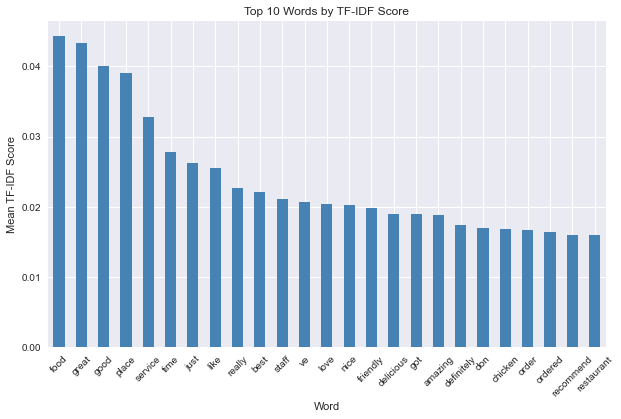

In [254]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Create TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = tfidf.fit_transform(df['text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names())  # Use get_feature_names for compatibility

# Meaning: This step initializes a TF-IDF vectorizer with English stop words removed and a limit of 1000 features,
# transforms the review text into a numerical matrix where each value reflects a word's importance (TF-IDF score),
# and converts it into a DataFrame with feature names as columns. TF-IDF balances word frequency and rarity across documents.
# Business Implication: This quantifies which words are most distinctive and relevant in reviews (e.g., 'service' over 'the'),
# providing a prioritized list of customer-focused topics to address or leverage for strategic planning.

# Step 2: Get top TF-IDF words
mean_tfidf = tfidf_df.mean().sort_values(ascending=False)
top_tfidf = mean_tfidf.head(25)
print("\nTop 10 Words by TF-IDF Score:")  # Corrected from Top 27 to Top 10
print(top_tfidf)

# Meaning: This calculates the mean TF-IDF score across all reviews for each word, sorts in descending order to identify importance,
# and selects the top 10 words. The updated print statement aligns with the data selection.
# Business Implication: The top words (e.g., 'great', 'poor') highlight key themes in customer feedback, with higher scores indicating
# significant or unique mentions. This guides businesses to focus on impactful areas (e.g., improving 'poor' experiences).

# Step 3: Visualize top TF-IDF words
plt.figure(figsize=(10, 6))
top_tfidf.plot(kind='bar', color='steelblue')
plt.title('Top 10 Words by TF-IDF Score')  # Corrected from Top 27 to Top 10
plt.xlabel('Word')
plt.ylabel('Mean TF-IDF Score')
plt.xticks(rotation=45)
plt.show()

**Observation:**

Process Significance**: The TF-IDF analysis converts raw text into a weighted representation, identifying words that are both frequent and distinctive, offering a sophisticated view of customer sentiment across reviews.

---
#### What unique things are customers saying across states? 
---

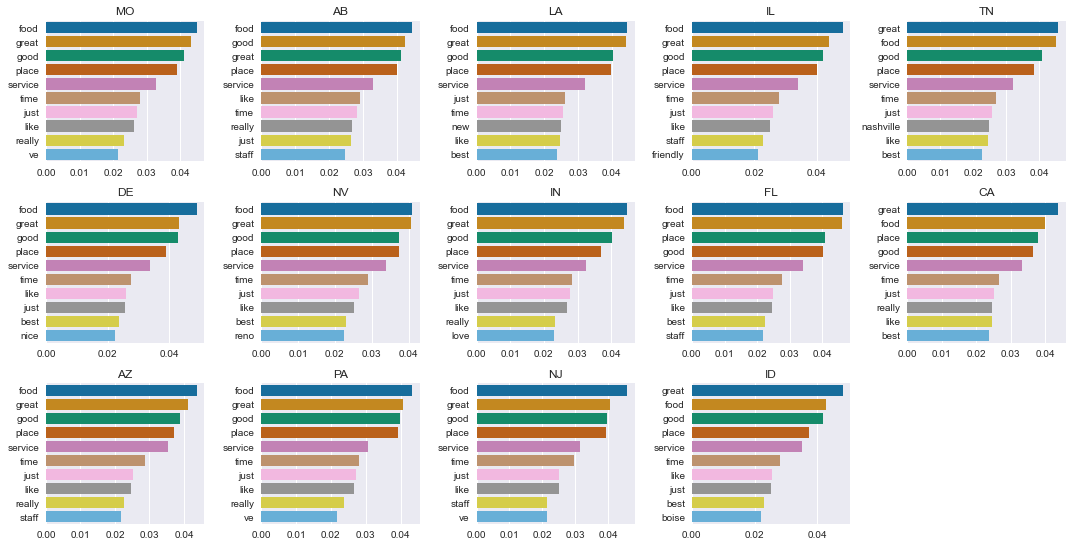

In [255]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define function to compute TF-IDF per state
def tfidf_top_words_by_state(df, text_col='text', group_col='state', top_n=20):
    results = []

    for state, group in df.groupby(group_col):
        if group[text_col].count() < 5:
            continue  # Skip states with very few reviews

        tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
        tfidf_matrix = tfidf.fit_transform(group[text_col])
        tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names())
        mean_tfidf = tfidf_df.mean().sort_values(ascending=False).head(top_n)

        for word, score in mean_tfidf.items():
            results.append({
                group_col: state,
                'word': word,
                'tfidf_score': score
            })

    return pd.DataFrame(results)

# Step 2: Run function
state_tfidf_df = tfidf_top_words_by_state(df, text_col='text', group_col='state', top_n=20)

# Step 3: Select top 10 states by review count
top_states = state_tfidf_df['state'].value_counts().nlargest(20).index.tolist()

# Step 4: Create a 3-column visualization
plt.figure(figsize=(15, 10))
for i, state in enumerate(top_states, 1):
    state_data = state_tfidf_df[state_tfidf_df['state'] == state].sort_values('tfidf_score', ascending=False).head(10)
    plt.subplot(4, 5, i)  # 2 rows, 5 columns for 10 states
    sns.barplot(x='tfidf_score', y='word', data=state_data, palette='colorblind')
    plt.title(state)
    plt.xlabel('')
    plt.ylabel('')
    plt.tight_layout()

plt.show()

**Observations**

---

**Missouri (MO)**

In Missouri, people love their **food** and value a **great** dining experience. Reviews often mention **good** service and a comfortable **place** to eat. Patrons highlight **service** and **time** efficiency, noting how staff are prompt. Words like **just**, **like**, and **really** suggest a conversational tone. Some mention **ve** — likely part of words like "we've" — hinting at shared experiences.

---

**Alabama (AB)**

In Alabama, customers describe **food** as **good** and the environment as **great**. The **place** often gets shoutouts for being cozy. While **service** gets discussed, people frequently use expressions like **like**, **really**, and **just** — implying a personal, laid-back narrative. **Time** is occasionally a concern, and **staff** are highlighted for their friendliness.

---

**Louisiana (LA)**

Louisiana reviews focus on **food**, **great** flavors, and **good** hospitality. Locals love their **place** to hang out and consistently talk about **service**. Words like **just**, **time**, and **new** suggest fresh experiences. **Like** and **best** round out the list, showing satisfaction with meals and ambiance.

---

**Illinois (IL)**

Illinois diners emphasize **food**, **great** service, and **good** experiences. The **place** is important to them — likely clean and welcoming. Discussions around **service**, **time**, and use of casual words like **just**, **like**, and **really** show personal engagement. A hint of local pride shines through.

---

**Tennessee (TN)**

Tennessee customers rave about **great** service and **food**, describing it as **good** and served in a pleasant **place**. **Time** and **just** appear often, showing an eye on efficiency. Mentions of **Nashville** reveal local pride. Words like **like** and **best** reinforce appreciation.

---

**Delaware (DE)**

In Delaware, **food** tops the charts, followed by **great** and **good** mentions about the experience. Patrons appreciate the **place** and **service**, especially when prompt. Words like **time**, **like**, and **just** reflect storytelling. Surprisingly, **rice** and **best** are standouts — maybe there's a popular rice dish?

---

**Nevada (NV)**

Nevada’s reviewers talk up **food**, **great** ambiance, and **good** experiences at their favorite **place**. **Service**, **time**, and expressions like **just**, **like**, and **best** show positive vibes. The word **reno** surfaces often, signaling that Reno is a hotspot.

---

**Indiana (IN)**

Indiana customers use words like **food**, **great**, and **good** to praise restaurants. **Place**, **service**, and **time** indicate what matters most. Casual phrases like **just**, **like**, and **really** appear often, suggesting relaxed, honest feedback. **Love** implies emotional satisfaction.

---

**Florida (FL)**

Floridians care about **food**, calling it **great**, and often use **good** to describe the vibe. The **place** and **service** are important, with **time** being a close concern. Words like **just**, **like**, and **really** give a warm tone. **Best** pops up regularly in praise.

---

**California (CA)**

In California, the word **great** leads, followed by **food**, **place**, and **good**. **Service** is praised, but Californians are time-conscious too. Casual review tones come through with **just**, **really**, and **like**. **Best** suggests a high bar for quality.

---

**Arizona (AZ)**

Arizona reviews focus on **food**, described as **great** and **good**. **Place** and **service** are essential, while **time** hints at speed expectations. Words like **just**, **like**, and **really** point to friendly reviews. **Staff** gets positive mentions, showing appreciation for people.

---

**Pennsylvania (PA)**

Pennsylvania residents praise their **food**, **great** atmosphere, and **good** service. They frequent a favorite **place** and value timely **service**. Terms like **time**, **just**, and **like** show storytelling. **Really** and **ve** (possibly "we’ve") suggest group experiences.

---

**New Jersey (NJ)**

New Jersey reviewers love their **food**, describing it as **great**, **good**, and worth the **place**. They mention **service** and **time** often, indicating expectations. Words like **just**, **like**, and **staff** hint at connection and respect. **Ve** appears as part of natural speech.

---

**Idaho (ID)**

Idaho reviews highlight **great** food and **good** vibes at the **place**. **Service** and **time** matter, and words like **like**, **just**, and **best** bring a casual, positive tone. **Boise** shows strong city pride.


---
#### What unique things (tf-idf) are customers saying in the top 10 categories?
---

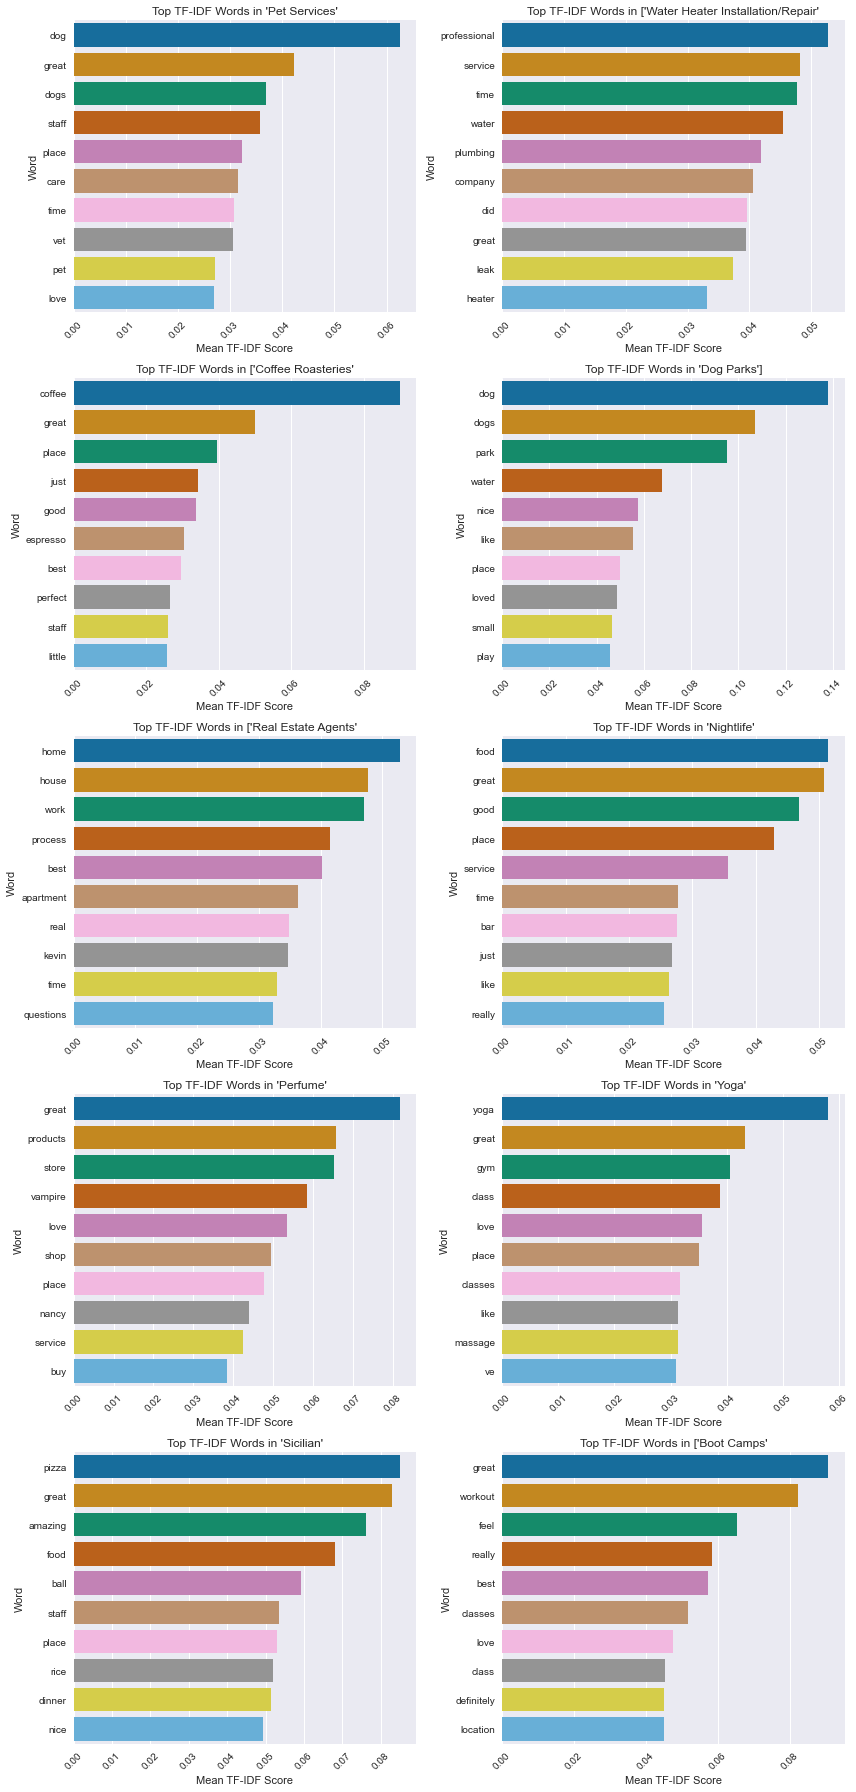

In [258]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Define function to compute TF-IDF per category
def tfidf_top_words_by_category(df, text_col='text', group_col='categories', top_n=10):
    results = []

    # Split categories string into list
    df[group_col] = df[group_col].str.split(', ')

    # Explode the dataframe to have one row per category per review
    df_exploded = df.explode(group_col)

    for category, group in df_exploded.groupby(group_col):
        if group[text_col].count() < 10:
            continue  # Skip categories with very few reviews

        tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
        tfidf_matrix = tfidf.fit_transform(group[text_col])
        tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names())
        mean_tfidf = tfidf_df.mean().sort_values(ascending=False).head(top_n)

        for word, score in mean_tfidf.items():
            results.append({
                group_col: category,
                'word': word,
                'tfidf_score': score
            })

    return pd.DataFrame(results)

# Step 2: Run function
category_tfidf_df = tfidf_top_words_by_category(df, text_col='text', group_col='categories', top_n=10)

# Step 3: Plot results for each category in two columns
top_categories = category_tfidf_df['categories'].value_counts().nlargest(16).index.tolist()

n_cols = 2  # Two columns
n_rows = (len(top_categories) + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows), squeeze=False)
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

for idx, category in enumerate(top_categories):
    data = category_tfidf_df[category_tfidf_df['categories'] == category].sort_values('tfidf_score', ascending=False)
    sns.barplot(x='tfidf_score', y='word', data=data, palette='colorblind', ax=axes[idx])
    axes[idx].set_title(f"Top TF-IDF Words in {category}")
    axes[idx].set_xlabel("Mean TF-IDF Score")
    axes[idx].set_ylabel("Word")
    axes[idx].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for idx in range(len(top_categories), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

---
### Bigram Analysis for Term Frequency (TF) by Inverse Document Frequency (IDF) generally referred as TF-IDF
---
**TF-IDF This adjusts for how common a word is across all documents. If “disrespectful employees” appears in just a few reviews but “good food” is everywhere, inverse document frequency reduces the weight of “good food” and boosts that of “disrespectful employees” because it’s more distinctive. The combination of TF and IDF gives you a score that highlights words that are both frequent in a document and rare across all documents—making them stand out as significant.**

In [259]:
# Step 1: Generate bigrams from tokenized text
# 'tokenize_text(x)' function defined above, tokenizes each review
# 'bigrams()' returns bigram tuples
# Then we join each bigram into a string like "good service"
df['bigrams'] = df['text'].apply(
    lambda x: [' '.join(bigram) for bigram in bigrams(tokenize_text(x))]
)

# Step 2: Count the frequency of all bigrams across all reviews
# flatten all bigrams from all rows into one list and count their frequency
bigram_freq = Counter([bigram for bigrams in df['bigrams'] for bigram in bigrams])

# Step 3: Create a DataFrame of the top 10 most common bigrams
top_bigrams = pd.DataFrame(bigram_freq.most_common(20), columns=['bigram', 'count'])
print("\nTop 20 Bigrams:")
print(top_bigrams)

# Step 4: Use TF-IDF to find important bigrams (not just frequent ones)
# Initialize TfidfVectorizer to extract bigrams (ngram_range=(2, 2)) and ignore stopwords
bigram_tfidf = TfidfVectorizer(stop_words='english', ngram_range=(2, 2), max_features=1000)

# Transform the raw text into a TF-IDF-weighted matrix of bigrams
bigram_tfidf_matrix = bigram_tfidf.fit_transform(df['text'])

# Convert the sparse matrix to a full DataFrame for analysis
bigram_tfidf_df = pd.DataFrame(
    bigram_tfidf_matrix.toarray(),
    columns=bigram_tfidf.get_feature_names()
)

# Step 5: Compute the average TF-IDF score for each bigram across all documents
mean_bigram_tfidf = bigram_tfidf_df.mean().sort_values(ascending=False)

# Select the top 10 bigrams by average TF-IDF score
top_bigram_tfidf = mean_bigram_tfidf.head(20)
print("\nTop 20 Bigrams by TF-IDF Score:")
print(top_bigram_tfidf)


Top 20 Bigrams:
              bigram  count
0   customer service   4363
1            go back   4152
2   highly recommend   4131
3         first time   4076
4          come back   3384
5        really good   3092
6          food good   2699
7          ice cream   2680
8          next time   2530
9        great place   2400
10        great food   2340
11     great service   2322
12       pretty good   2183
13       even though   2159
14        every time   2151
15         make sure   2111
16       new orleans   2108
17         good food   2062
18   would recommend   2048
19    staff friendly   2047

Top 20 Bigrams by TF-IDF Score:
customer service    0.017500
highly recommend    0.017443
food good           0.010297
really good         0.010219
great service       0.009957
great place         0.009871
staff friendly      0.009533
great food          0.009416
ice cream           0.008924
love place          0.008561
make sure           0.008395
food great          0.008200
new orleans   

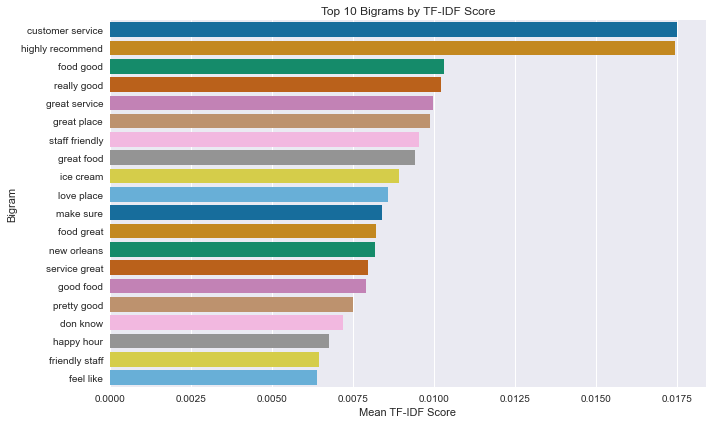

In [260]:
# Step 6: Visualize the top 10 bigrams based on TF-IDF scores for the general corpus

import seaborn as sns
import matplotlib.pyplot as plt

top_df = top_bigram_tfidf.reset_index()
top_df.columns = ['bigram', 'score']

plt.figure(figsize=(10, 6))
sns.barplot(x='score', y='bigram', data=top_df, palette='colorblind')
plt.title('Top 10 Bigrams by TF-IDF Score')
plt.xlabel('Mean TF-IDF Score')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

**Observation:** 

1) The highest scoring bigrams (based on their importance and uniqueness across documents) are as shown above for the entire corpus. 

2) Quality-focused phrases like “customer service,” “great food,” “staff friendly,” and “highly recommend” suggest that positive experiences and service dominate the reviews.

3) Food-related terms (e.g., “food good,” “ice cream,” “great food”) are also prominent, likely indicating food establishments. 

We will drill further into this corpus to identify bigrams for the top 10 bigrams for the respective states and then for top 10 business categories to see what customers are saying across states and business categories.

---
#### Bigrams for things customers frequently say versus significant things they said.
---

In [261]:
### Step 1: Compute Top 10 TF Bigrams per State
def compute_tf_bigrams_per_state(df):
    # Extract bigrams
    df['bigrams'] = df['text'].apply(lambda x: [' '.join(bg) for bg in bigrams(tokenize_text(x))])
    
    # Flatten and count bigrams per state
    bigram_counts = (
        df.explode('bigrams')
          .groupby(['state', 'bigrams'])
          .size()
          .reset_index(name='count')
    )
    
    # Top 10 per state
    top_tf_bigrams = (
        bigram_counts.groupby('state')
          .apply(lambda x: x.nlargest(10, 'count'))
          .reset_index(drop=True)
    )
    
    return top_tf_bigrams

In [262]:
def compute_tfidf_bigrams_per_state(df, top_n=10):
    tfidf_results = []

    for state, group in df.groupby('state'):
        vectorizer = TfidfVectorizer(ngram_range=(2, 2), stop_words='english', max_features=1000)
        try:
            tfidf_matrix = vectorizer.fit_transform(group['text'])
            features = vectorizer.get_feature_names()
            scores = tfidf_matrix.mean(axis=0).A1
            top_idx = scores.argsort()[::-1][:top_n]
            
            for i in top_idx:
                tfidf_results.append({
                    'state': state,
                    'bigram': features[i],
                    'score': scores[i]
                })
        except ValueError:
            continue

    return pd.DataFrame(tfidf_results)

In [263]:
def plot_bigrams_per_state(tf_df, tfidf_df, state):
    tf_data = tf_df[tf_df['state'] == state].sort_values('count', ascending=True)
    tfidf_data = tfidf_df[tfidf_df['state'] == state].sort_values('score', ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # TF Plot
    sns.barplot(x='count', y='bigrams', data=tf_data, ax=axes[0], palette='colorblind')
    axes[0].set_title(f"Top 10 TF Bigrams in {state}")
    axes[0].set_xlabel("Count")
    axes[0].set_ylabel("Bigram")

    # TF-IDF Plot
    sns.barplot(x='score', y='bigram', data=tfidf_data, ax=axes[1], palette='colorblind')
    axes[1].set_title(f"Top 10 TF-IDF Bigrams in {state}")
    axes[1].set_xlabel("TF-IDF Score")
    axes[1].set_ylabel("Bigram")

    plt.tight_layout()
    plt.show()

Showing bigram analysis for state: AB


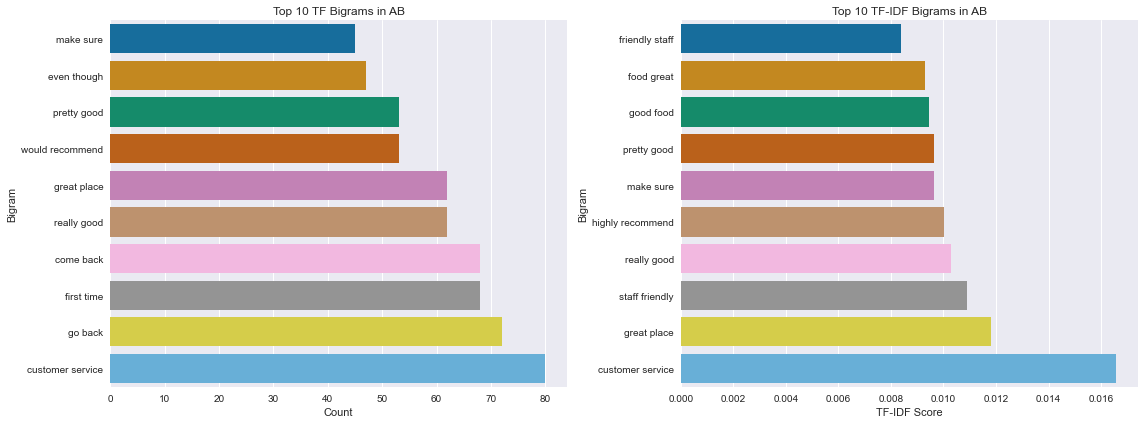

Showing bigram analysis for state: AZ


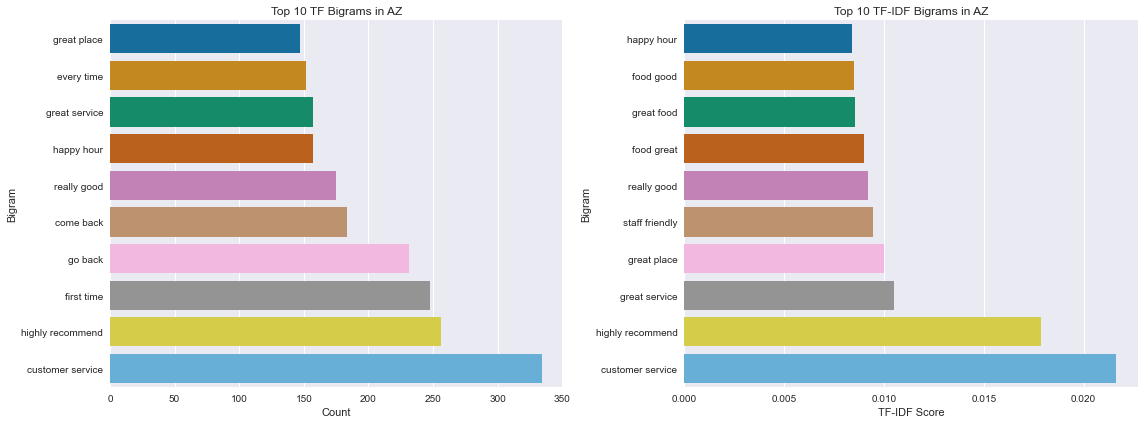

Showing bigram analysis for state: CA


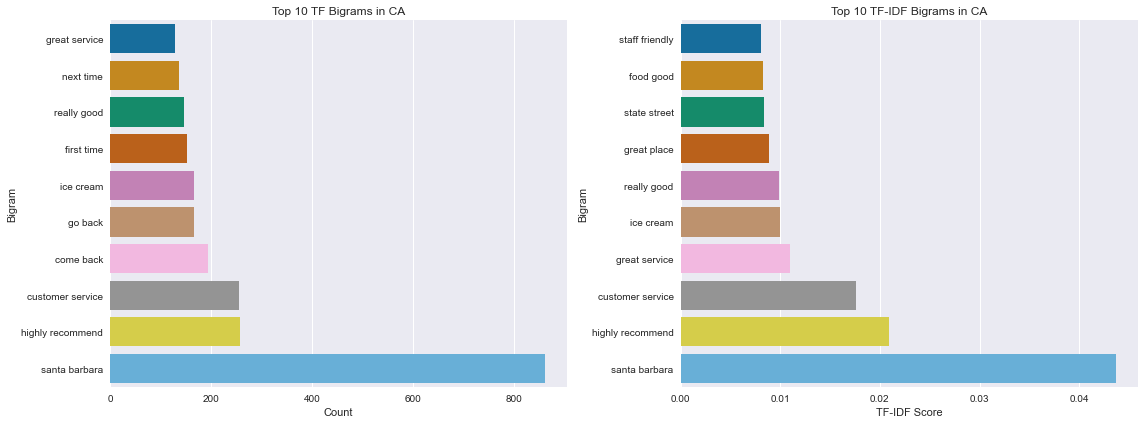

Showing bigram analysis for state: CO


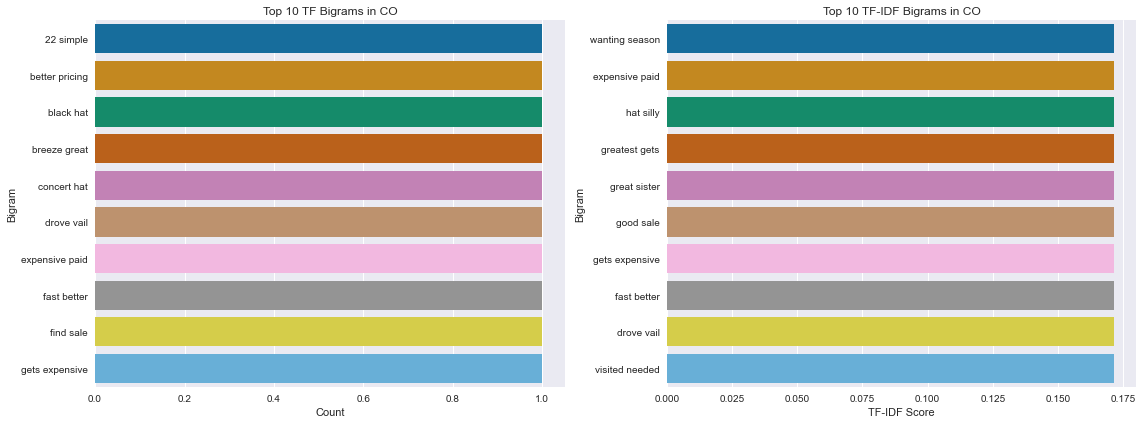

Showing bigram analysis for state: DE


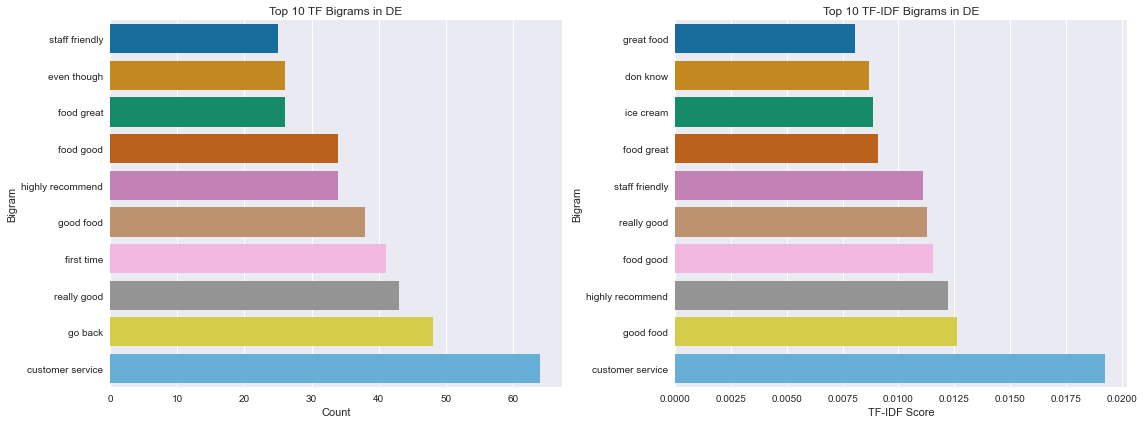

Showing bigram analysis for state: FL


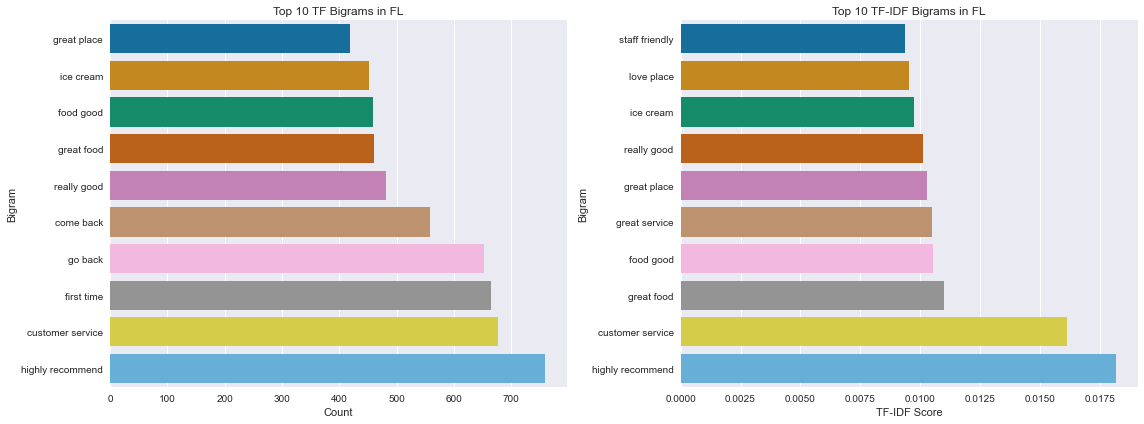

Showing bigram analysis for state: HI


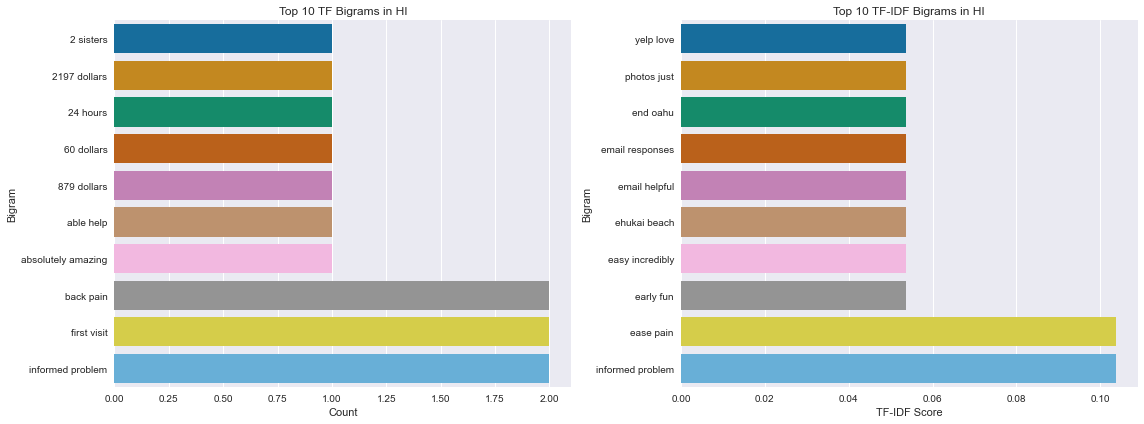

Showing bigram analysis for state: ID


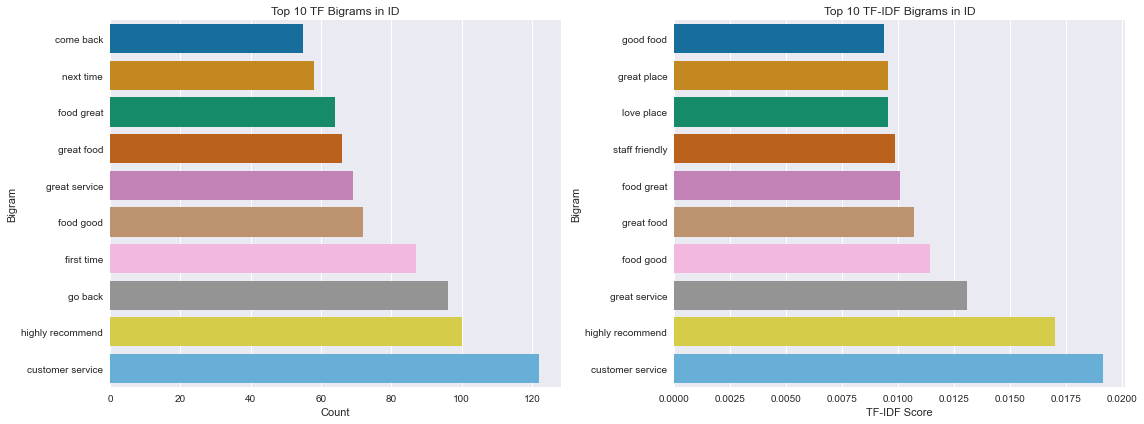

Showing bigram analysis for state: IL


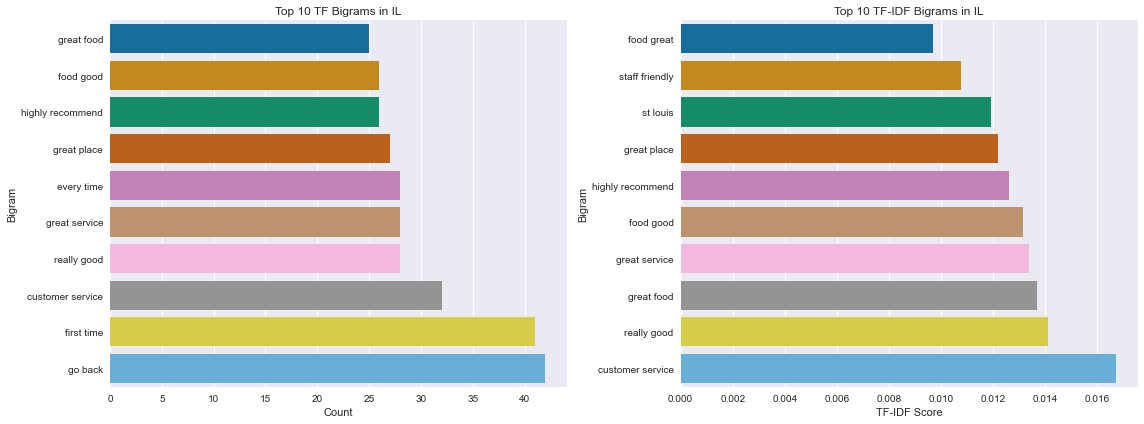

Showing bigram analysis for state: IN


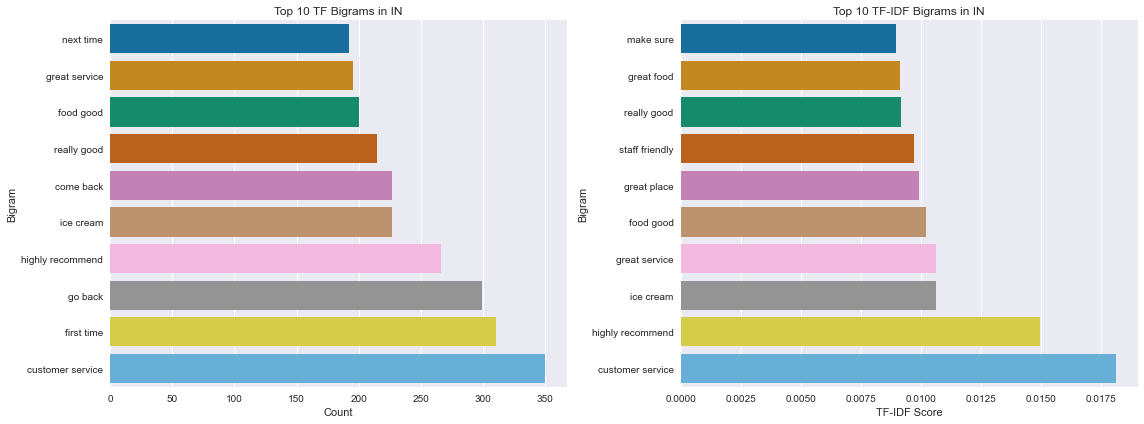

Showing bigram analysis for state: LA


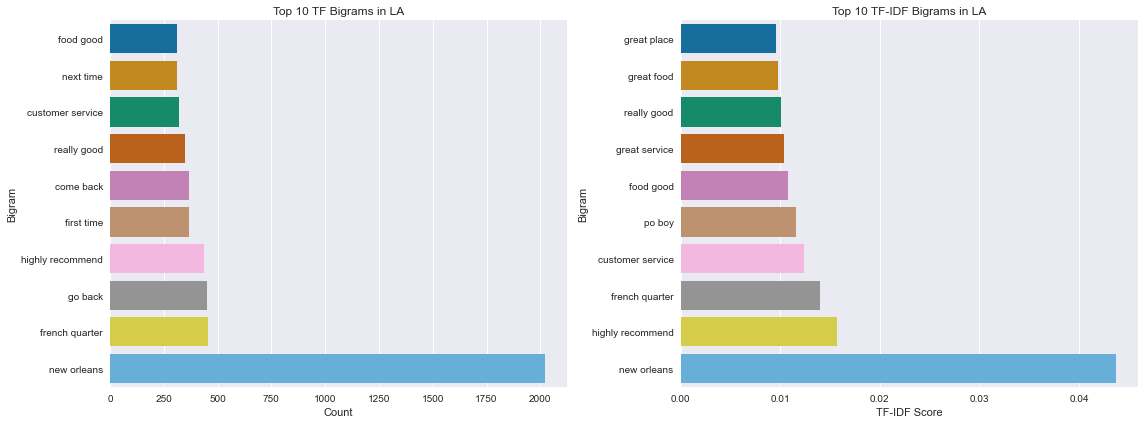

Showing bigram analysis for state: MO


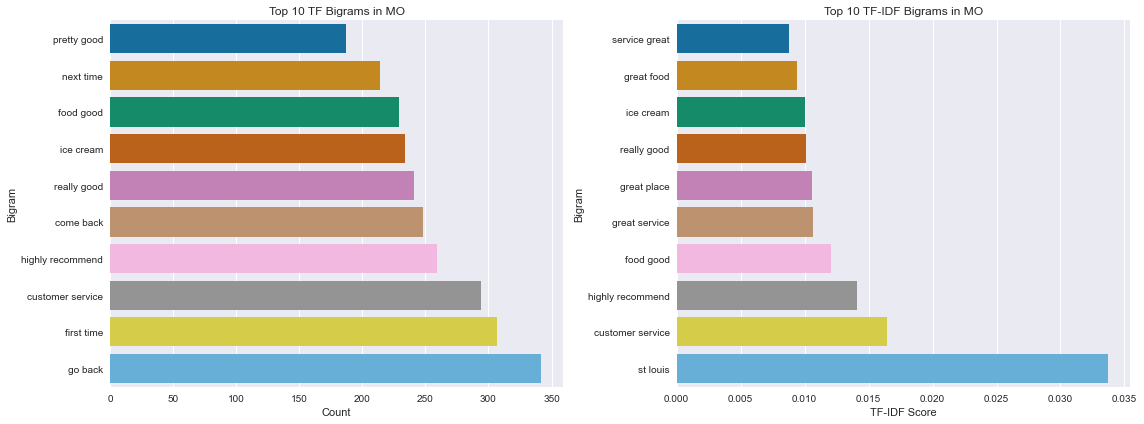

Showing bigram analysis for state: NJ


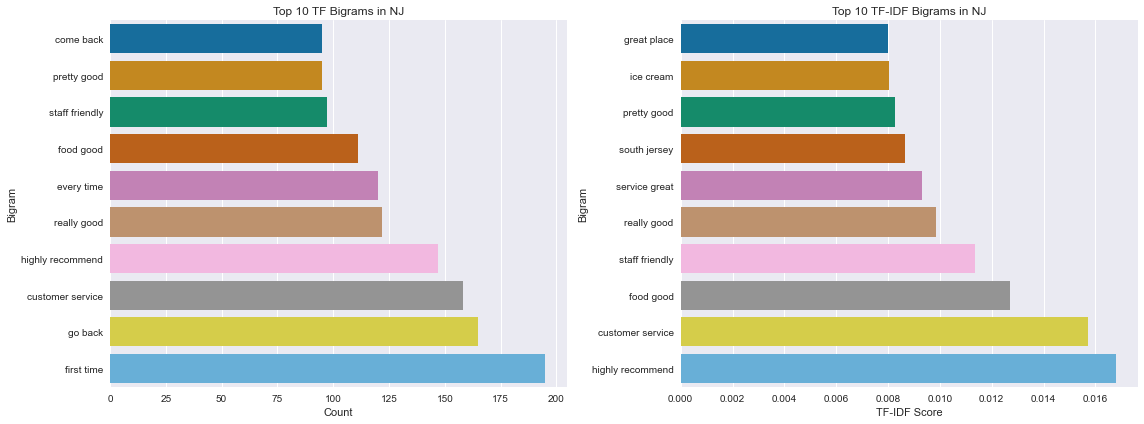

Showing bigram analysis for state: NV


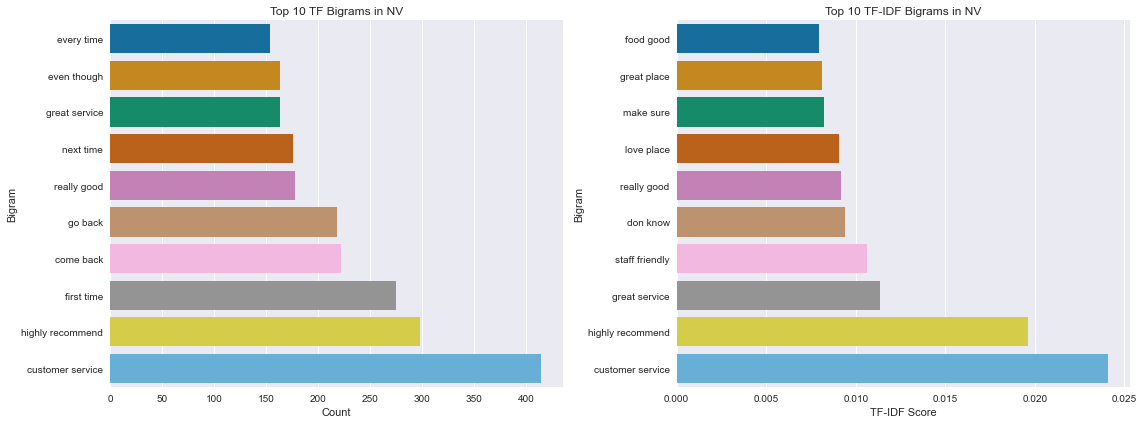

Showing bigram analysis for state: PA


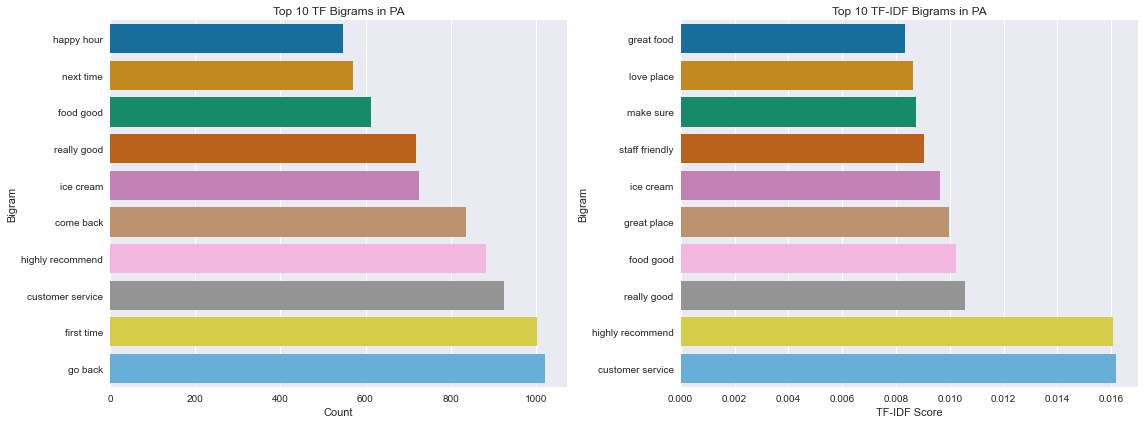

Showing bigram analysis for state: SD


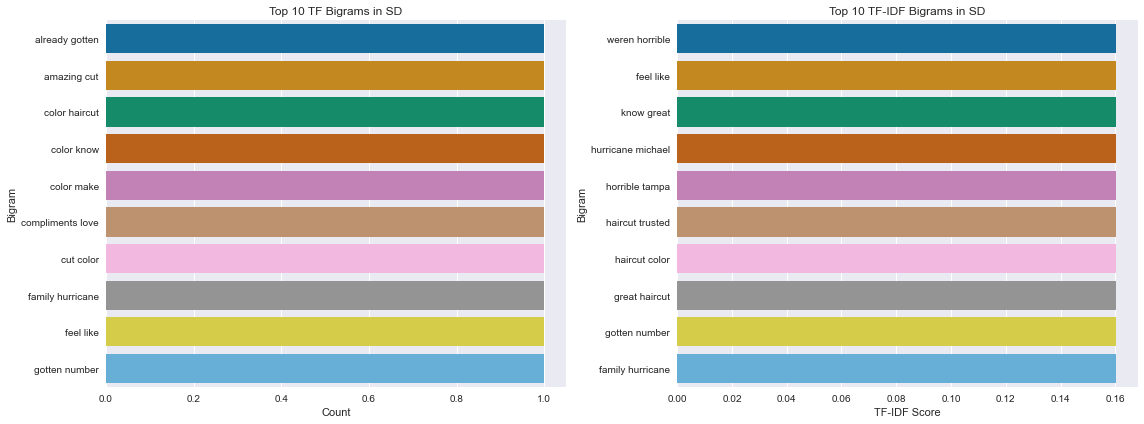

Showing bigram analysis for state: TN


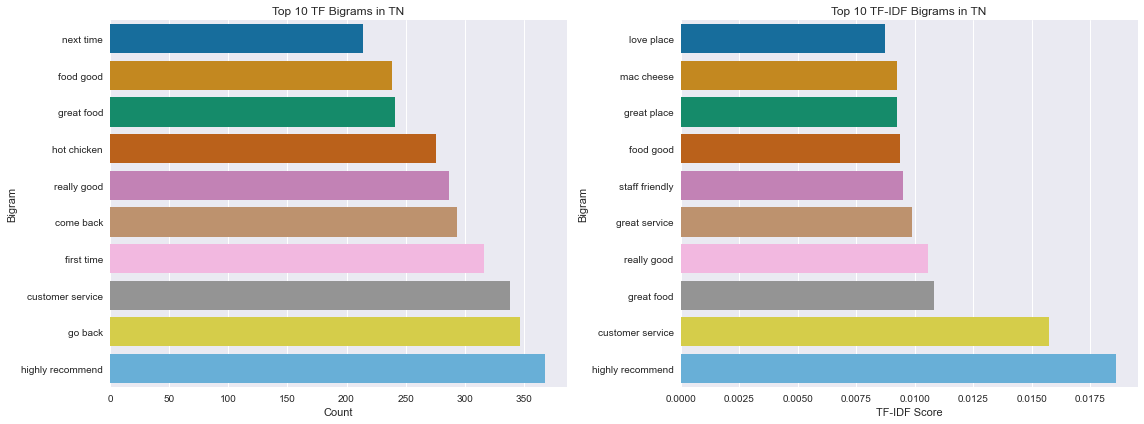

Showing bigram analysis for state: TX


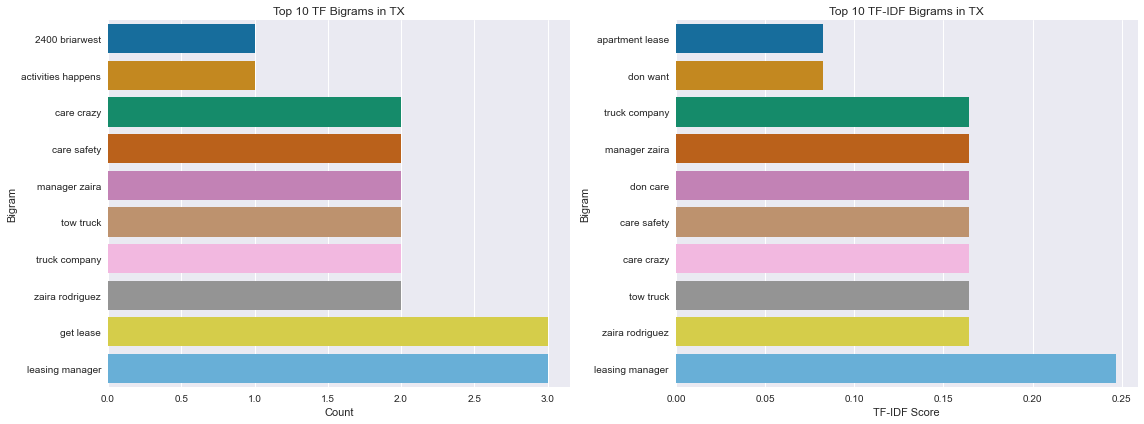

Showing bigram analysis for state: UT


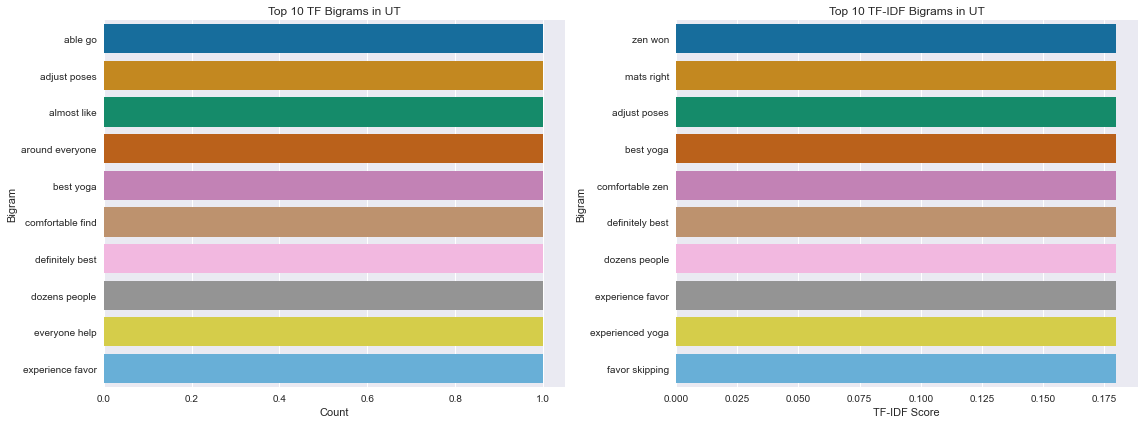

In [264]:
# Visualize bigrams for tf and tf-idf side by side
top_tf_bigrams = compute_tf_bigrams_per_state(df)
top_tfidf_bigrams = compute_tfidf_bigrams_per_state(df)

# Visualize for a few example states
for state in sorted(df['state'].unique()):
    print(f"Showing bigram analysis for state: {state}")
    plot_bigrams_per_state(top_tf_bigrams, top_tfidf_bigrams, state)

**Observations:**

What customers uniquely say are more important that what is frequently said as shown side by side for the respective states. The TF-IDF score frequency shows where the focus is on by customers. For example, in the state of TN, customer would "highly recommend" businesses because of great "customer service".

---
#### Top Bigrams Per Category
---

In [272]:
import pandas as pd

# Group bigrams by category and count frequency
# Ensure categories is a string by joining list elements if it contains lists
df['categories'] = df['categories'].apply(lambda x: ', '.join(x) if isinstance(x, list) else x)

bigram_by_category = (
    df.explode('bigrams')
      .groupby(['categories', 'bigrams'])
      .size()
      .reset_index(name='count')
)

# Get top 5 bigrams per category
top_bigrams_per_category = (
    bigram_by_category.groupby('categories')
      .apply(lambda x: x.nlargest(5, 'count'))
      .reset_index(drop=True)
)

print("Top 5 Bigrams per Category:")
print(top_bigrams_per_category.head(15))  # show sample

Top 5 Bigrams per Category:
                                           categories             bigrams  \
0                                             Unknown           18 months   
1                                             Unknown       building live   
2                                             Unknown  completely ignored   
3                                             Unknown           could get   
4                                             Unknown            day call   
5   ["Children's Clothing", "Women's Clothing", "M...             3 stars   
6   ["Children's Clothing", "Women's Clothing", "M...           able find   
7   ["Children's Clothing", "Women's Clothing", "M...         across mall   
8   ["Children's Clothing", "Women's Clothing", "M...     always pleasant   
9   ["Children's Clothing", "Women's Clothing", "M...   authentic strives   
10  ["Children's Clothing", "Women's Clothing", 'B...     additional cost   
11  ["Children's Clothing", "Women's Clothing", 

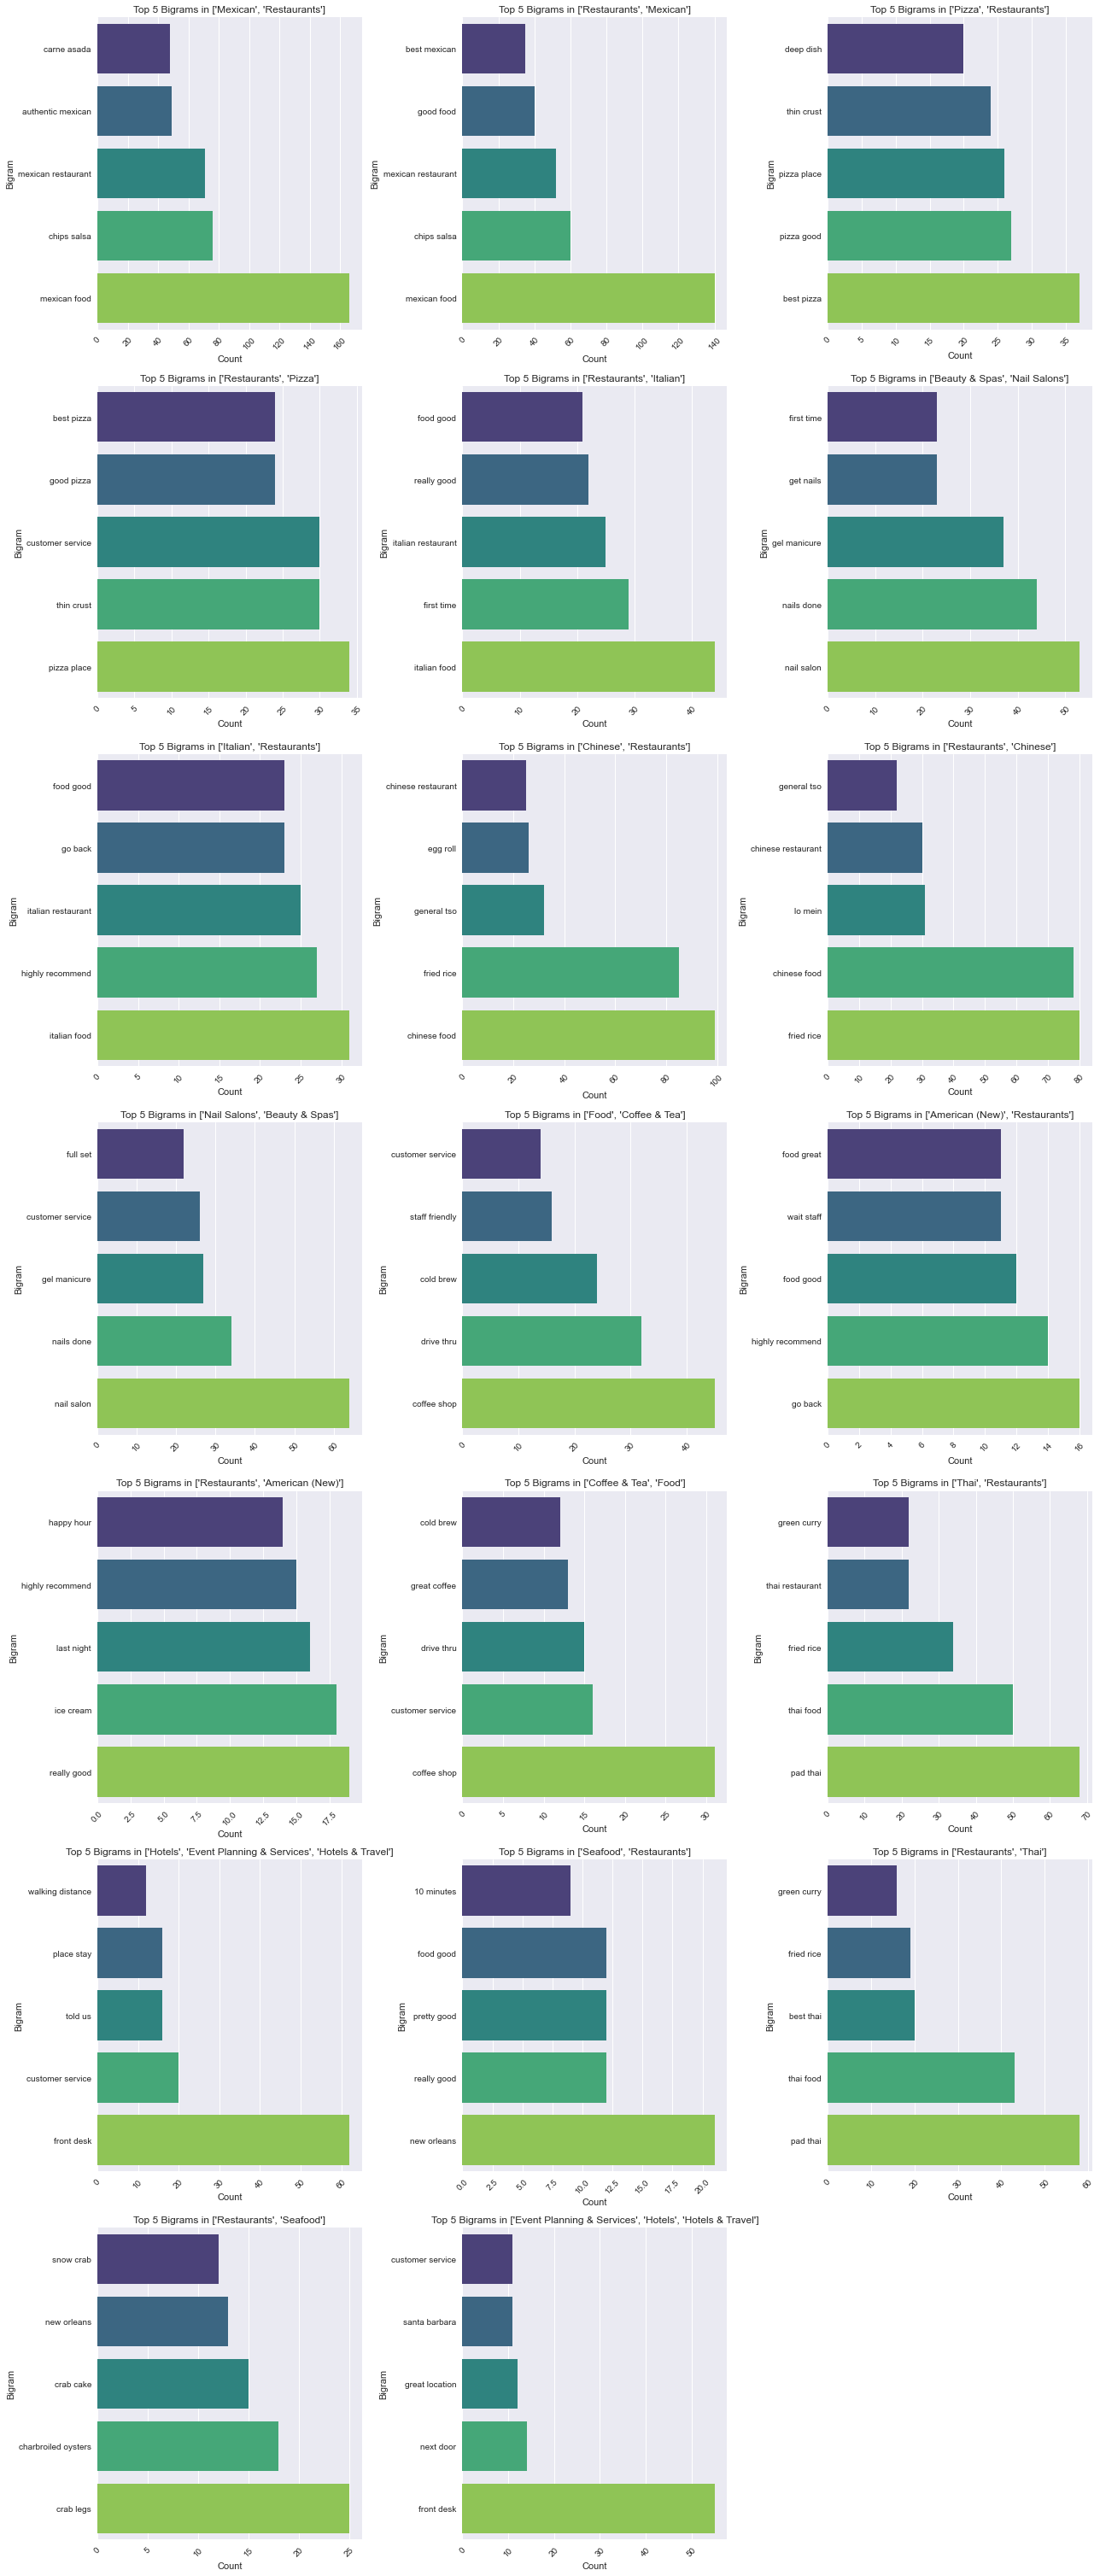

In [282]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.util import bigrams

# Step 4: Visualization function with subplot support
def plot_top_bigrams_by_category(ax, df, category_name):
    data = df[df['categories'] == category_name].sort_values('count', ascending=True)

    if data.empty:
        ax.set_title(f"No data for: {category_name}")
        ax.axis('off')
        return

    sns.barplot(x='count', y='bigrams', data=data, palette='viridis', ax=ax)
    ax.set_title(f"Top 5 Bigrams in {category_name}")
    ax.set_xlabel("Count")
    ax.set_ylabel("Bigram")
    ax.tick_params(axis='x', rotation=45)

# Step 5: Plot top 20 most frequent categories in three columns
top_categories = df['categories'].value_counts().nlargest(20).index.tolist()

n_cols = 3  # Three columns
n_rows = (len(top_categories) + n_cols - 1) // n_cols  # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), squeeze=False)
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

for idx, cat in enumerate(top_categories):
    plot_top_bigrams_by_category(axes[idx], top_bigrams_per_category, cat)

# Hide any unused subplots
for idx in range(len(top_categories), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

---
### Trigram Creation and Inspection for what's frequently said (tf) versus what is uniquely said by customers (tf-idf)
---
How does this work? 

If df['text'] = ["Food was very good and fresh"], then 

df['trigrams'] = [['food was very', 'was very good', 'very good and', 'good and fresh']]

In [283]:
from nltk.util import bigrams, trigrams

def tokenize_text(text):
    return text.lower().split()  # Basic tokenizer — customize as needed


# -----------------------------
# TRIGRAM Creation
# -----------------------------
# 'trigrams', just like 'bigrams' comes from "nltk.util.bigrams"
df['trigrams'] = df['text'].apply( # apply() applies a function to each row of the text column.
    lambda x: [' '.join(tg) for tg in trigrams(tokenize_text(x))]
)

# preview result
print("\nSample Trigrams:")
print(df[['text', 'trigrams']].head())



Sample Trigrams:
                                                text  \
0  Lots of choices on the menu. I had a delicious...   
1  Ashley M. Was PHENOMENAL! Met every, extremely...   
2  I am very disappointed to say that I was not h...   
3  This is one of the best places in that area. A...   
4  Amazing Ribs with a nice smokey flavor. Can't ...   

                                            trigrams  
0  [lots of choices, of choices on, choices on th...  
1  [ashley m. was, m. was phenomenal!, was phenom...  
2  [i am very, am very disappointed, very disappo...  
3  [this is one, is one of, one of the, of the be...  
4  [amazing ribs with, ribs with a, with a nice, ...  


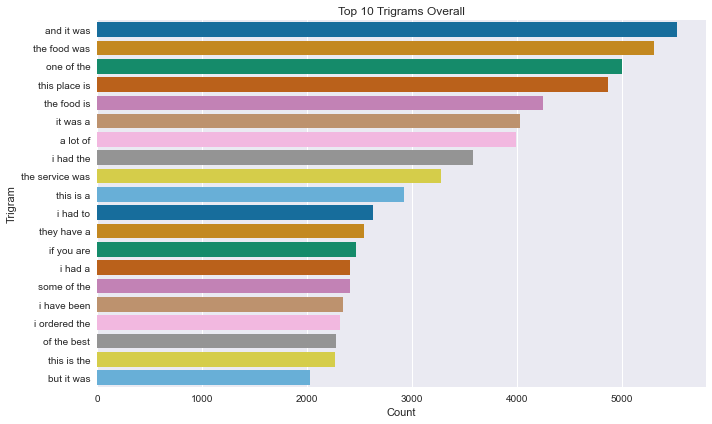

In [285]:
# Count Most Frequent Trigrams Overall

# Flatten all trigrams across reviews
all_trigrams = [tg for trigrams_list in df['trigrams'] for tg in trigrams_list]

# Count frequency
trigram_freq = Counter(all_trigrams)

# Create dataframe of top trigrams
top_trigrams = pd.DataFrame(trigram_freq.most_common(20), columns=['trigram', 'count'])

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='trigram', data=top_trigrams, palette='colorblind')
plt.title('Top 10 Trigrams Overall')
plt.xlabel('Count')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()

# You can further remove specific words like "and", "it", "the" as you wish. But, we will look at TF-IDF before 
# we decide to do this. 

In [286]:
# Count trigrams per business category 
trigram_by_category = (
    df.explode('trigrams')
      .groupby(['categories', 'trigrams'])
      .size()
      .reset_index(name='count')
)

top_trigrams_per_category = (
    trigram_by_category.groupby('categories')
      .apply(lambda x: x.nlargest(5, 'count'))
      .reset_index(drop=True)
)

In [287]:
# Count trigrams per state 
trigram_by_state = (
    df.explode('trigrams')
      .groupby(['state', 'trigrams'])
      .size()
      .reset_index(name='count')
)

top_trigrams_per_state = (
    trigram_by_state.groupby('state')
      .apply(lambda x: x.nlargest(5, 'count'))
      .reset_index(drop=True)
)

In [288]:
# TF-IDF Trigrams per Category and per State
# define function 

def tfidf_trigrams_by_group(df, group_col, top_n=5):
    results = []

    for group, group_df in df.groupby(group_col):
        vectorizer = TfidfVectorizer(ngram_range=(3, 3), stop_words='english', max_features=1000)
        try:
            tfidf_matrix = vectorizer.fit_transform(group_df['text'])
            features = vectorizer.get_feature_names()
            mean_scores = tfidf_matrix.mean(axis=0).A1
            top_idx = mean_scores.argsort()[::-1][:top_n]

            for i in top_idx:
                results.append({
                    group_col: group,
                    'trigram': features[i],
                    'score': mean_scores[i]
                })
        except ValueError:
            continue

    return pd.DataFrame(results)

In [289]:
# Apply to category and STate 
top_tfidf_trigrams_cat = tfidf_trigrams_by_group(df, group_col='categories')
top_tfidf_trigrams_state = tfidf_trigrams_by_group(df, group_col='state')

In [290]:
# Visualize Tri-gram frequencies 
def plot_top_trigrams_freq(df, group_col, group_val):
    data = df[df[group_col] == group_val].sort_values('count', ascending=True)
    if data.empty:
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(x='count', y='trigrams', data=data, palette='colorblind')
    plt.title(f"Top Trigrams in {group_val} ({group_col})")
    plt.xlabel('Count')
    plt.ylabel('Trigram')
    plt.tight_layout()
    plt.show()

In [291]:
# Visualize TF-IDF plot 
def plot_top_trigrams_tfidf(df, group_col, group_val):
    data = df[df[group_col] == group_val].sort_values('score', ascending=True)
    if data.empty:
        return

    plt.figure(figsize=(10, 6))
    sns.barplot(x='score', y='trigram', data=data, palette='colorblind')
    plt.title(f"Top TF-IDF Trigrams in {group_val} ({group_col})")
    plt.xlabel('Mean TF-IDF Score')
    plt.ylabel('Trigram')
    plt.tight_layout()
    plt.show()

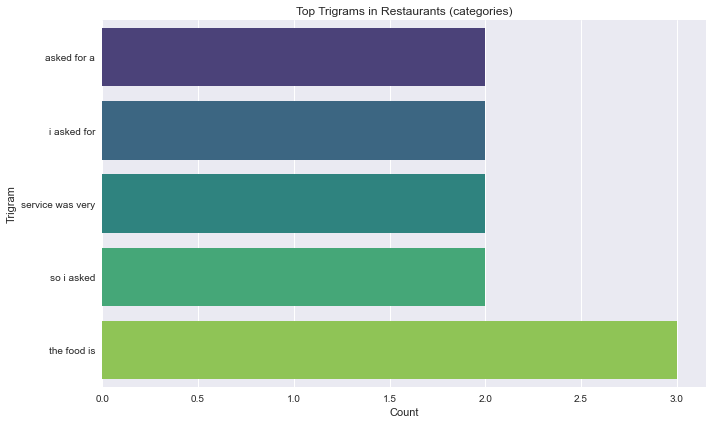

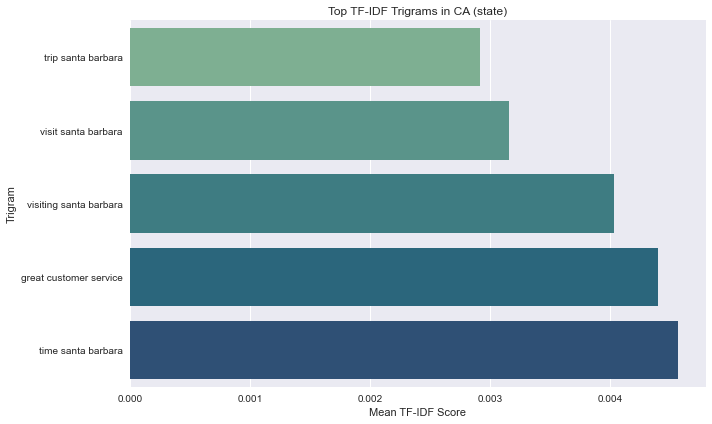

In [129]:
### Visualize trigram frequency for category of interest and state 

# Visualize top trigram frequencies in category "Restaurants"
plot_top_trigrams_freq(top_trigrams_per_category, group_col='categories', group_val='Restaurants')

# Visualize top TF-IDF trigrams in state "CA"
plot_top_trigrams_tfidf(top_tfidf_trigrams_state, group_col='state', group_val='CA')


In [130]:
#----------------------------------------------------------
# Function to Plot Side-by-Side (TF vs TF-IDF)
#----------------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

def plot_tf_vs_tfidf_trigrams(tf_df, tfidf_df, group_col, group_val):
    tf_data = tf_df[tf_df[group_col] == group_val].sort_values('count', ascending=True)
    tfidf_data = tfidf_df[tfidf_df[group_col] == group_val].sort_values('score', ascending=True)

    if tf_data.empty and tfidf_data.empty:
        print(f"No data for {group_col} = {group_val}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot TF
    sns.barplot(x='count', y='trigrams', data=tf_data, ax=axes[0], palette='Blues_d')
    axes[0].set_title(f"Top TF Trigrams in {group_val}")
    axes[0].set_xlabel("Frequency")
    axes[0].set_ylabel("Trigram")

    # Plot TF-IDF
    sns.barplot(x='score', y='trigram', data=tfidf_data, ax=axes[1], palette='Greens_d')
    axes[1].set_title(f"Top TF-IDF Trigrams in {group_val}")
    axes[1].set_xlabel("TF-IDF Score")
    axes[1].set_ylabel("Trigram")

    plt.tight_layout()
    plt.show()

In [131]:
#----------------------------------------------------------
# Trigram frequency data - what's often said by customers
#----------------------------------------------------------

from nltk.util import trigrams
from collections import Counter

# Generate trigram column
df['trigrams'] = df['text'].apply(lambda x: [' '.join(tg) for tg in trigrams(tokenize_text(x))])

# Frequency per category
trigram_by_category = (
    df.explode('trigrams')
      .groupby(['categories', 'trigrams'])
      .size()
      .reset_index(name='count')
)

top_trigrams_per_category = (
    trigram_by_category.groupby('categories')
      .apply(lambda x: x.nlargest(5, 'count'))
      .reset_index(drop=True)
)

# Frequency per state
trigram_by_state = (
    df.explode('trigrams')
      .groupby(['state', 'trigrams'])
      .size()
      .reset_index(name='count')
)

top_trigrams_per_state = (
    trigram_by_state.groupby('state')
      .apply(lambda x: x.nlargest(5, 'count'))
      .reset_index(drop=True)
)

In [133]:
#----------------------------------------------------------
# Trigram TD-IDF data - what’s uniquely important
#----------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_trigrams_by_group(df, group_col, top_n=5):
    results = []

    for group, group_df in df.groupby(group_col):
        vectorizer = TfidfVectorizer(ngram_range=(3, 3), stop_words='english', max_features=1000)
        try:
            tfidf_matrix = vectorizer.fit_transform(group_df['text'])
            features = vectorizer.get_feature_names()
            scores = tfidf_matrix.mean(axis=0).A1
            top_idx = scores.argsort()[::-1][:top_n]

            for i in top_idx:
                results.append({
                    group_col: group,
                    'trigram': features[i],
                    'score': scores[i]
                })
        except ValueError:
            continue

    return pd.DataFrame(results)

# Run for category and state
top_tfidf_trigrams_cat = tfidf_trigrams_by_group(df, group_col='categories')
top_tfidf_trigrams_state = tfidf_trigrams_by_group(df, group_col='state')


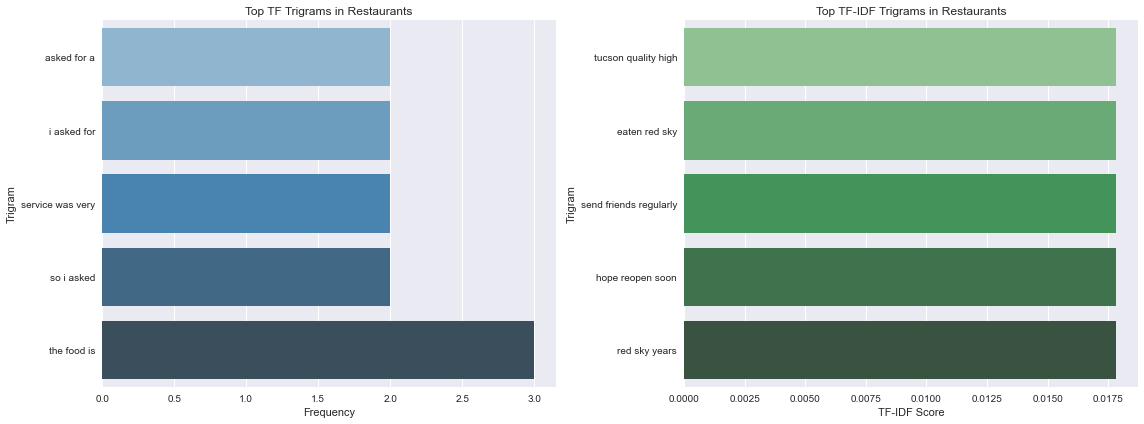

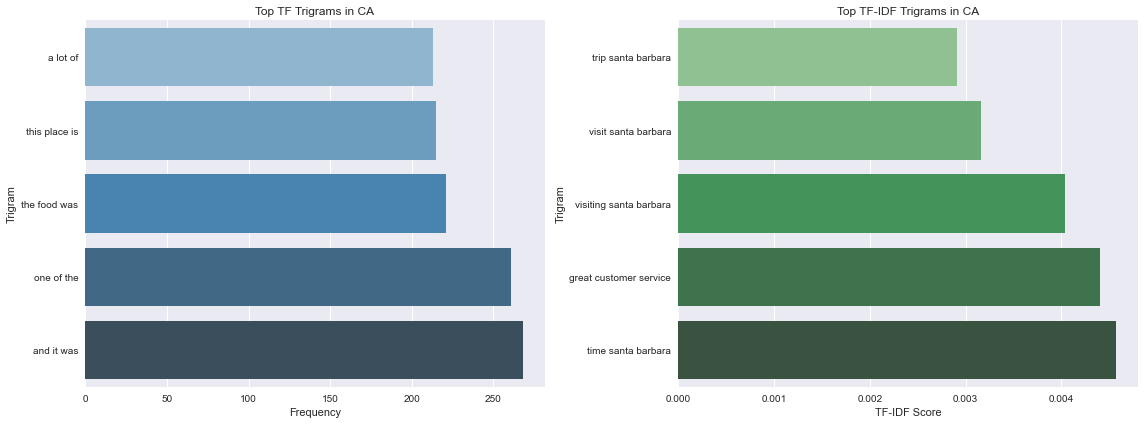

In [134]:
# Example 1: Compare TF vs TF-IDF trigrams for category "Restaurants"
plot_tf_vs_tfidf_trigrams(
    tf_df=top_trigrams_per_category,
    tfidf_df=top_tfidf_trigrams_cat,
    group_col='categories',
    group_val='Restaurants'
)

# Example 2: Compare for state "CA"
plot_tf_vs_tfidf_trigrams(
    tf_df=top_trigrams_per_state,
    tfidf_df=top_tfidf_trigrams_state,
    group_col='state',
    group_val='CA'
)

In [135]:
 # Full Function to Loop Through Groups
def loop_and_plot_all_trigrams(tf_df, tfidf_df, group_col):
    group_vals = tf_df[group_col].unique()

    for val in sorted(group_vals):
        print(f"\n Showing plots for {group_col}: {val}")
        plot_tf_vs_tfidf_trigrams(
            tf_df=tf_df,
            tfidf_df=tfidf_df,
            group_col=group_col,
            group_val=val
        )

In [137]:
# Run for All Categories, most often said (term frequency) vs What is uniquely said (TF-IDF)
#loop_and_plot_all_trigrams(
    #tf_df=top_trigrams_per_category,
    #tfidf_df=top_tfidf_trigrams_cat,
    #group_col='categories'
#)


 Showing plots for categories: Beauty & Spas, Nail Salons


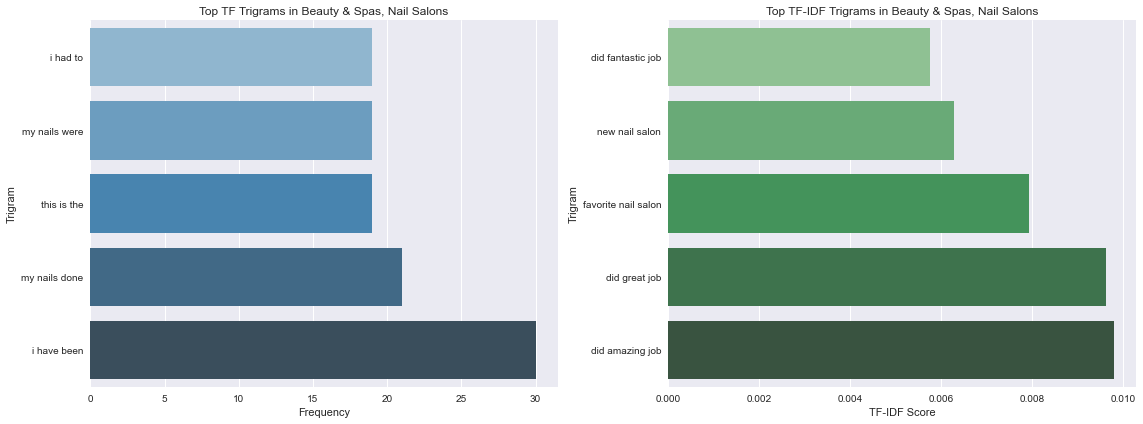


 Showing plots for categories: Chinese, Restaurants


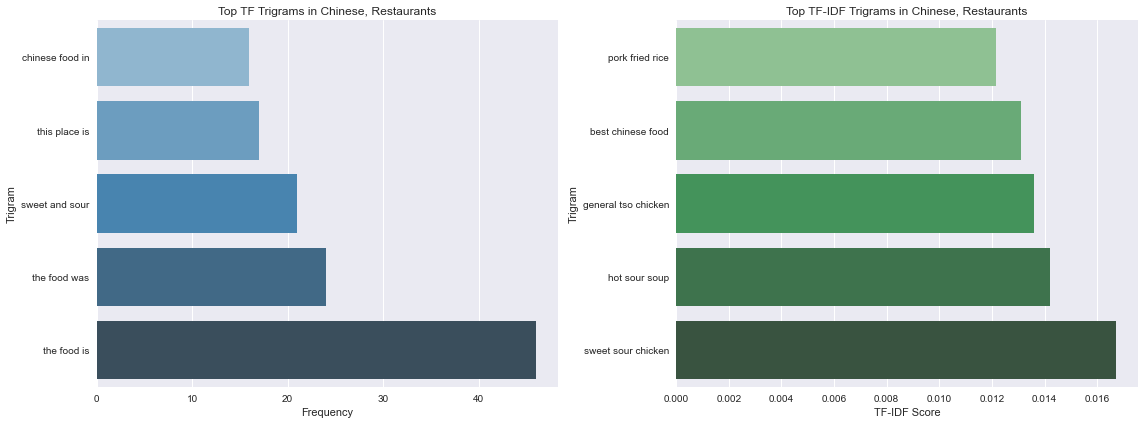


 Showing plots for categories: Italian, Restaurants


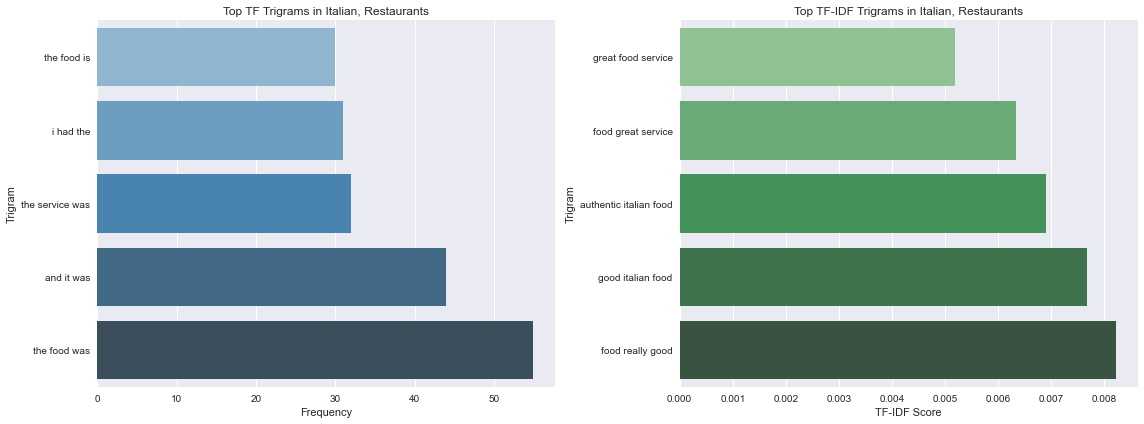


 Showing plots for categories: Mexican, Restaurants


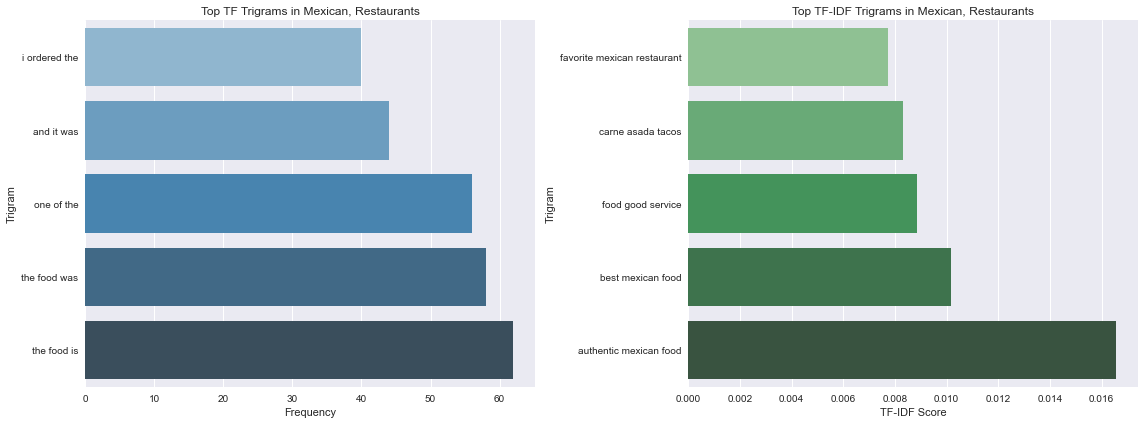


 Showing plots for categories: Nail Salons, Beauty & Spas


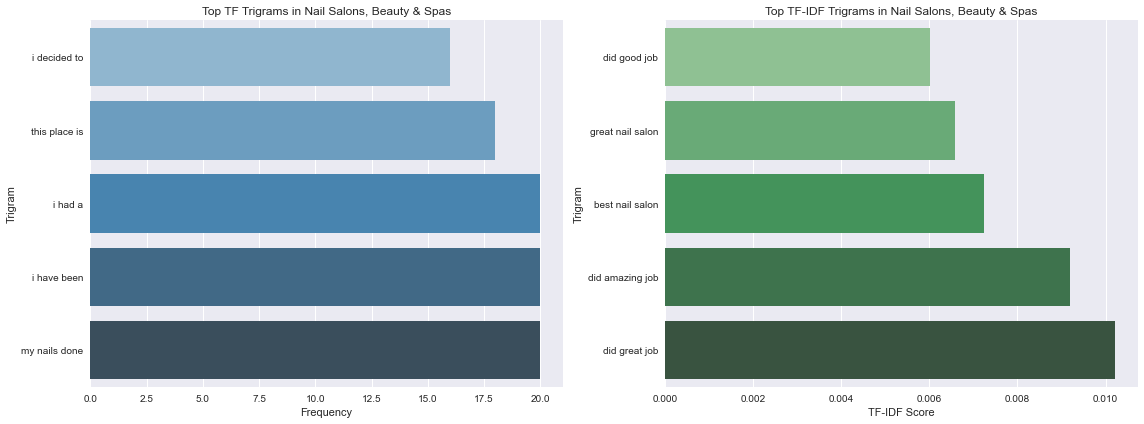


 Showing plots for categories: Pizza, Restaurants


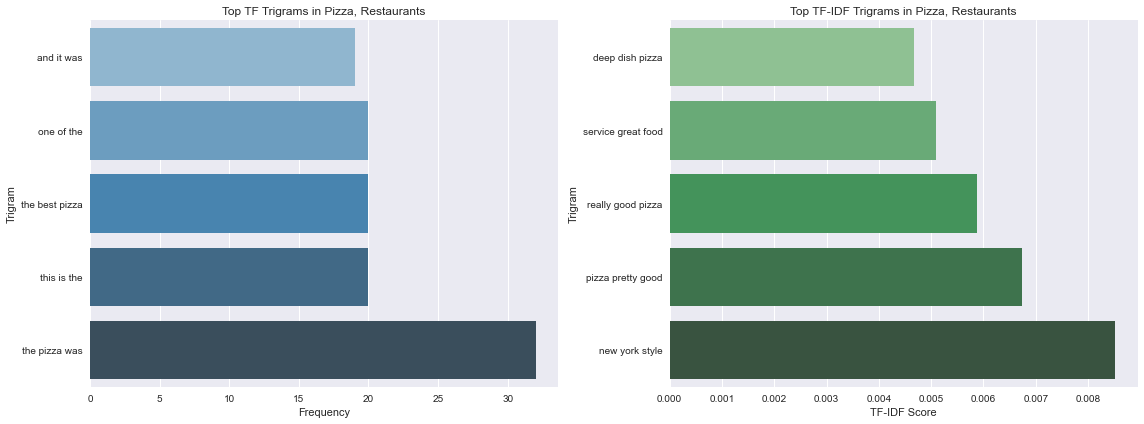


 Showing plots for categories: Restaurants, Chinese


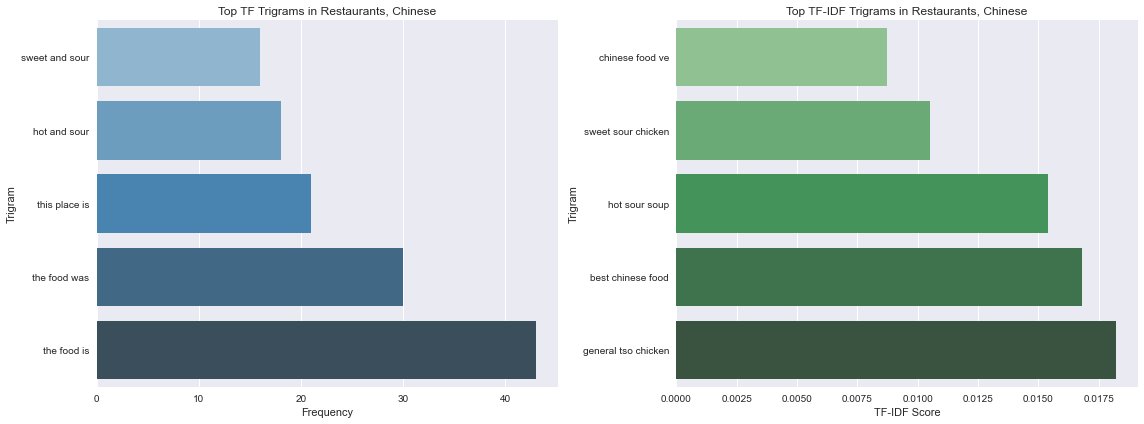


 Showing plots for categories: Restaurants, Italian


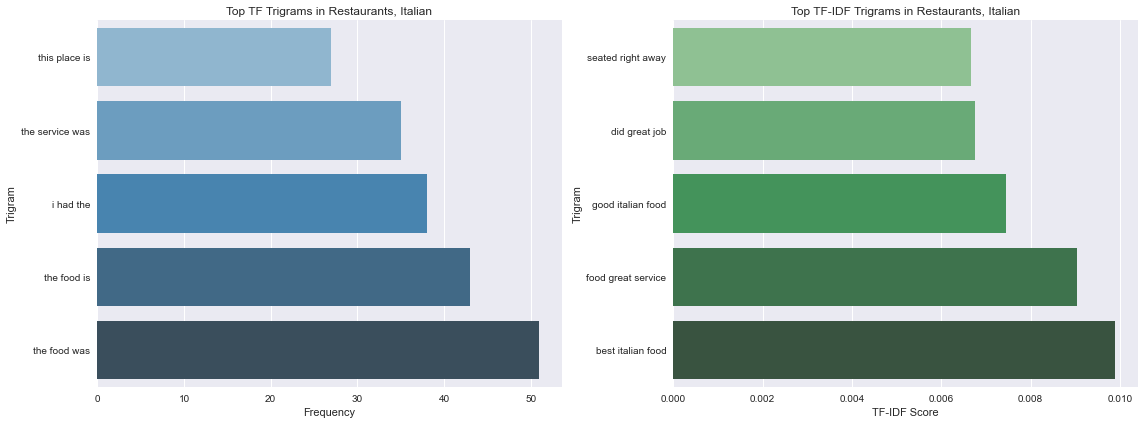


 Showing plots for categories: Restaurants, Mexican


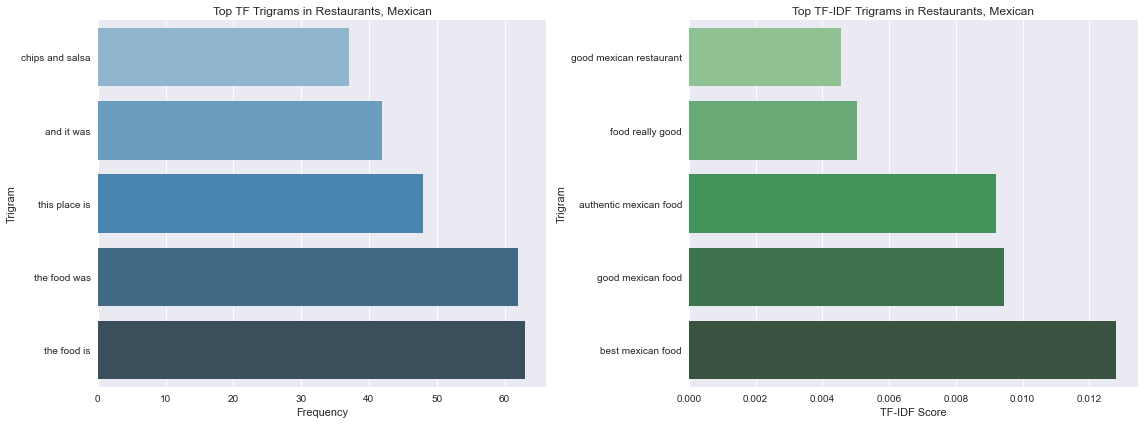


 Showing plots for categories: Restaurants, Pizza


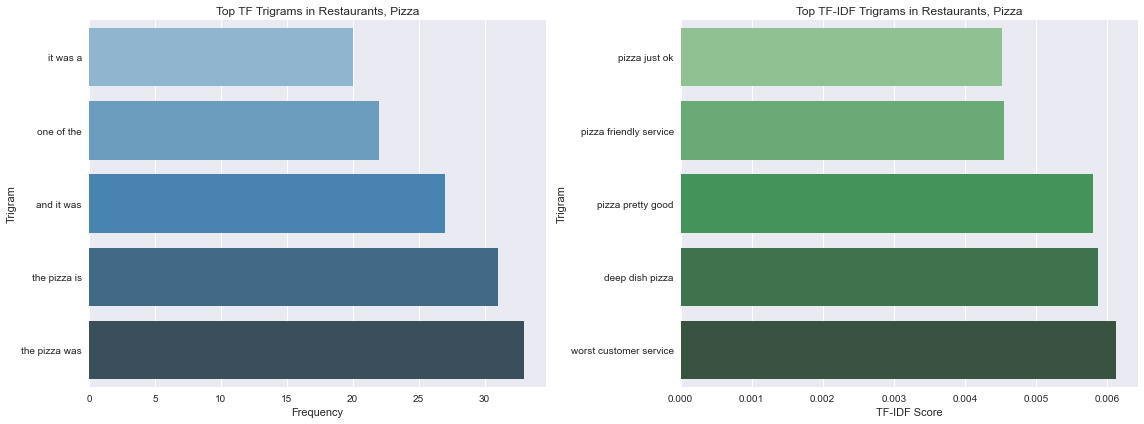

In [138]:
# Run for top 10 Categories, most often said (term frequency) vs What is uniquely said (TF-IDF)
# This would return restaurants only since majory of the reviews were on restaurants o this corpus 

# Get top 10 most common categories
top_10_categories = df['categories'].value_counts().nlargest(10).index.tolist()

# Filter trigram dataframes
filtered_tf = top_trigrams_per_category[top_trigrams_per_category['categories'].isin(top_10_categories)]
filtered_tfidf = top_tfidf_trigrams_cat[top_tfidf_trigrams_cat['categories'].isin(top_10_categories)]

# Plot only top 10 categories
loop_and_plot_all_trigrams(
    tf_df=filtered_tf,
    tfidf_df=filtered_tfidf,
    group_col='categories'
)

In [ ]:
---
#### Run for all states for what's often said (TF) and what's uniquely said (TD-IDF)
---


 Showing plots for state: AB


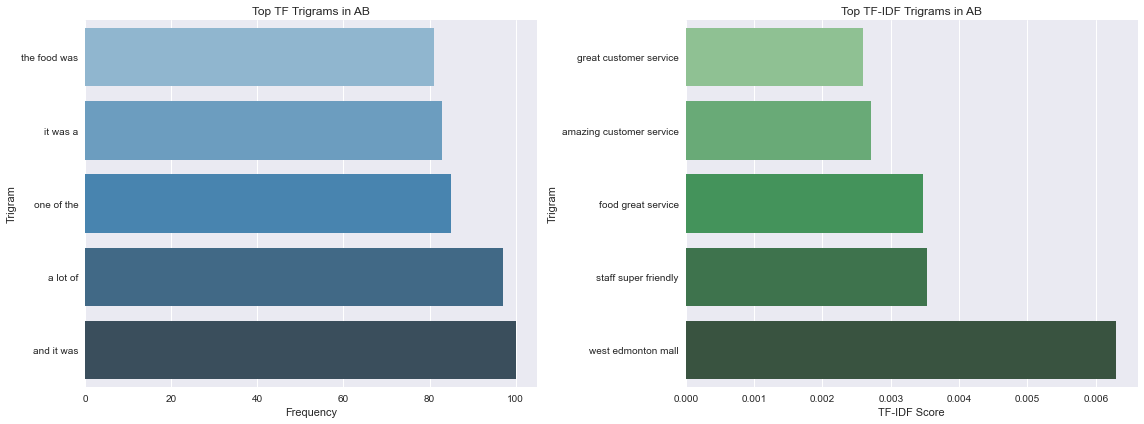


 Showing plots for state: AZ


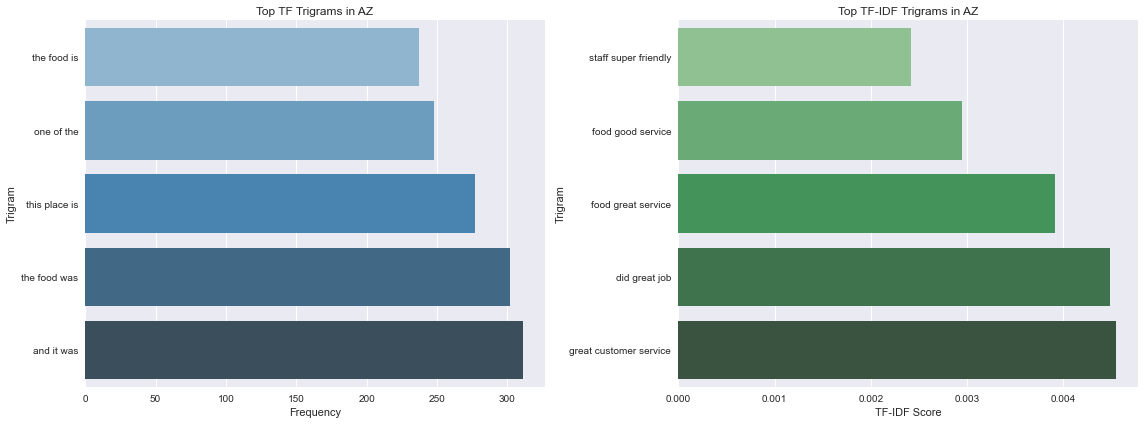


 Showing plots for state: CA


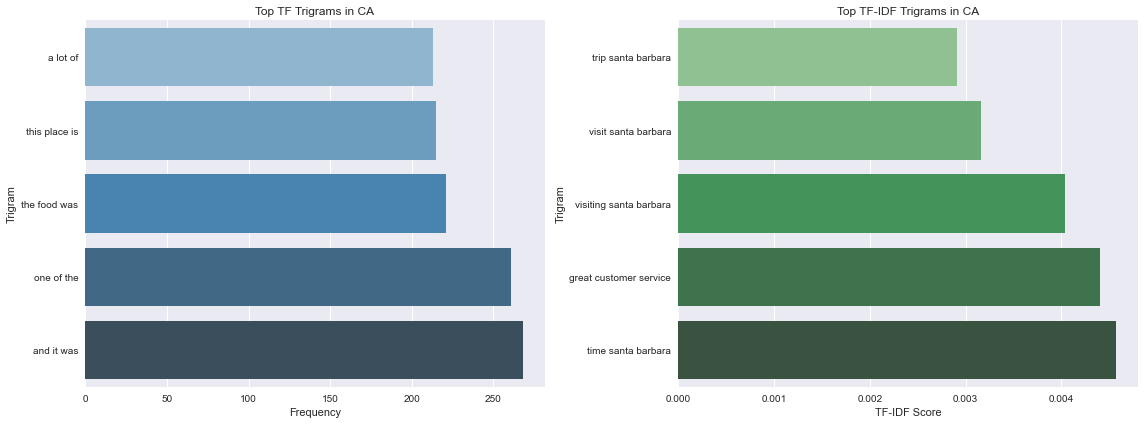


 Showing plots for state: CO


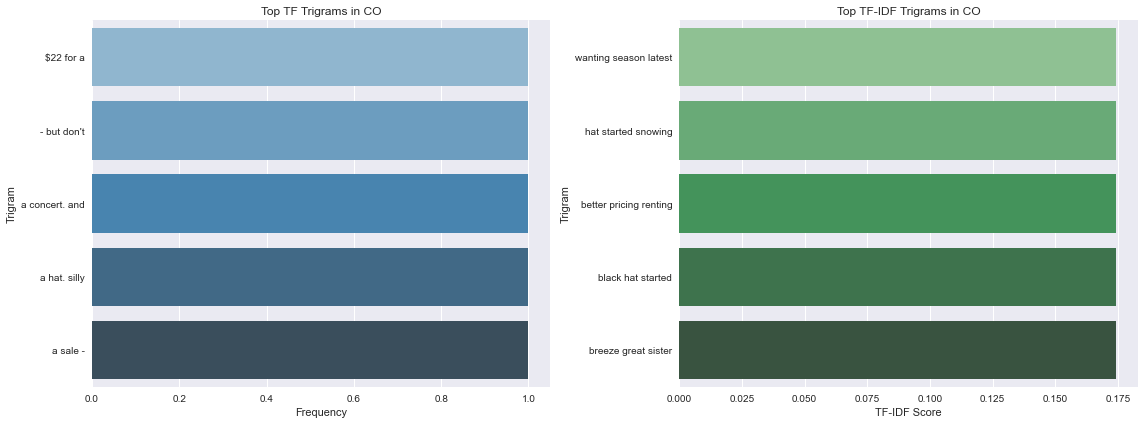


 Showing plots for state: DE


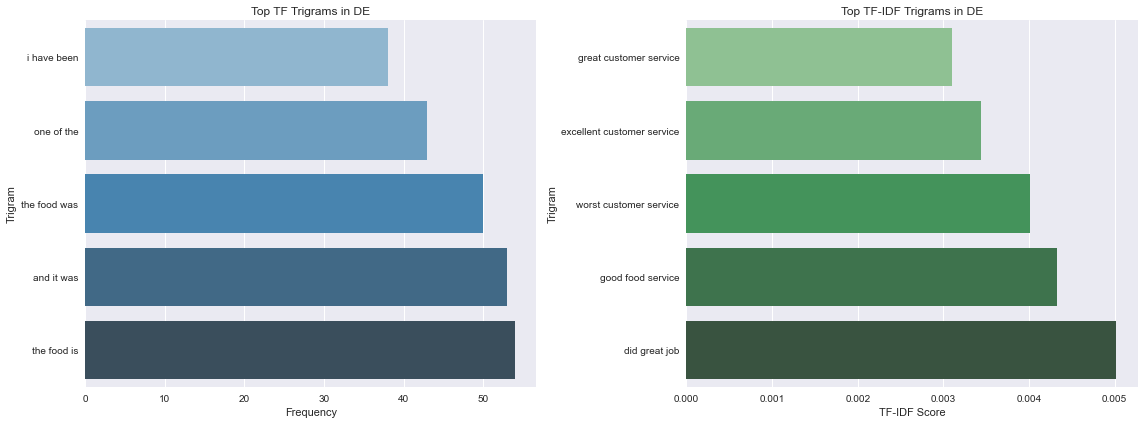


 Showing plots for state: FL


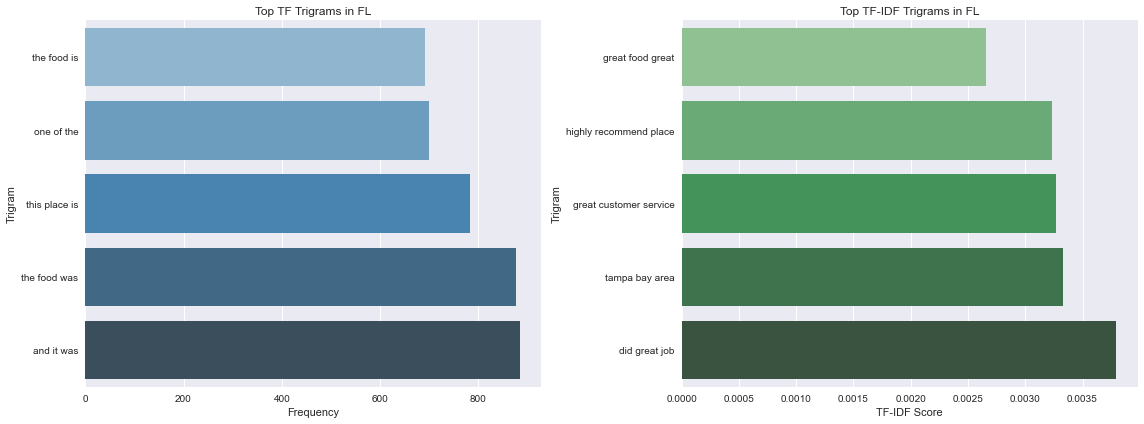


 Showing plots for state: HI


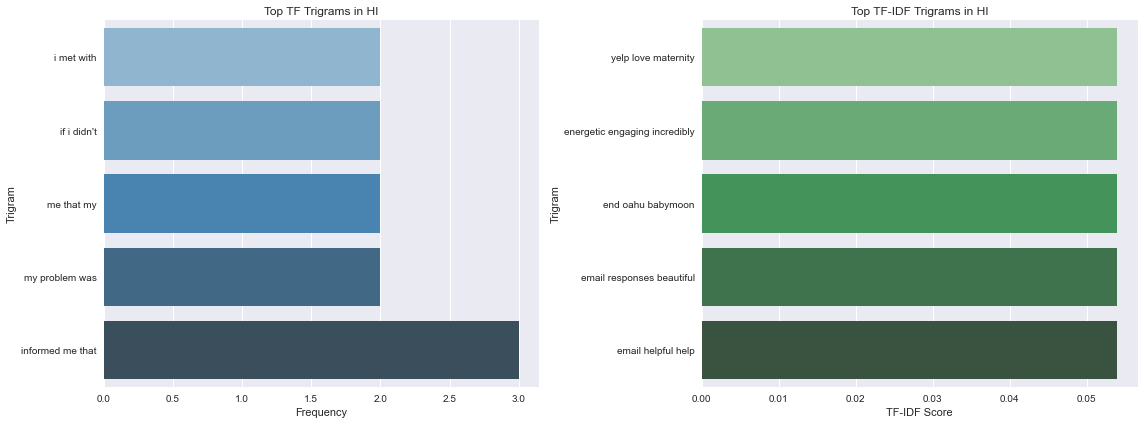


 Showing plots for state: ID


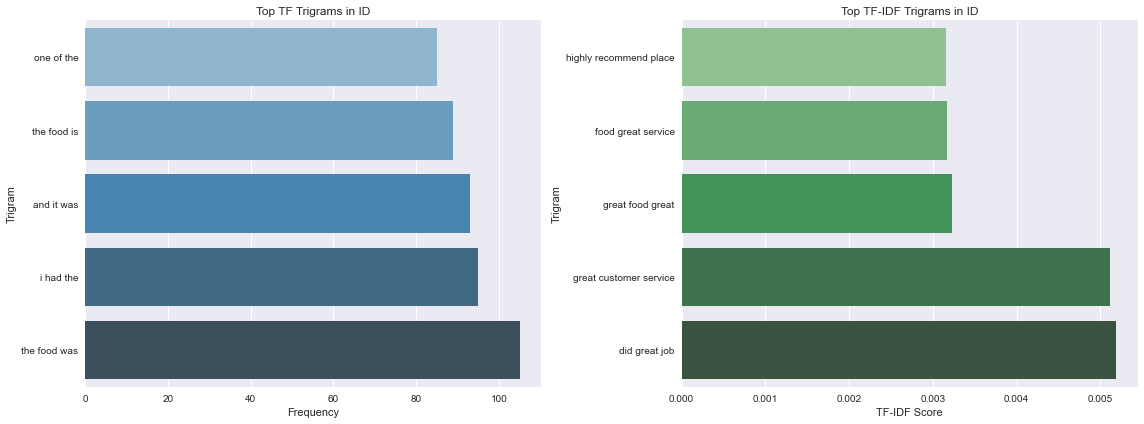


 Showing plots for state: IL


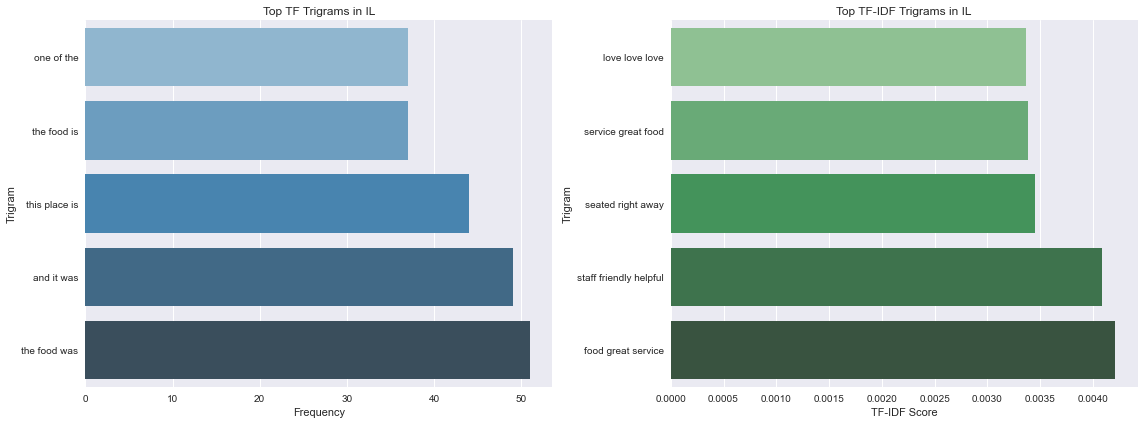


 Showing plots for state: IN


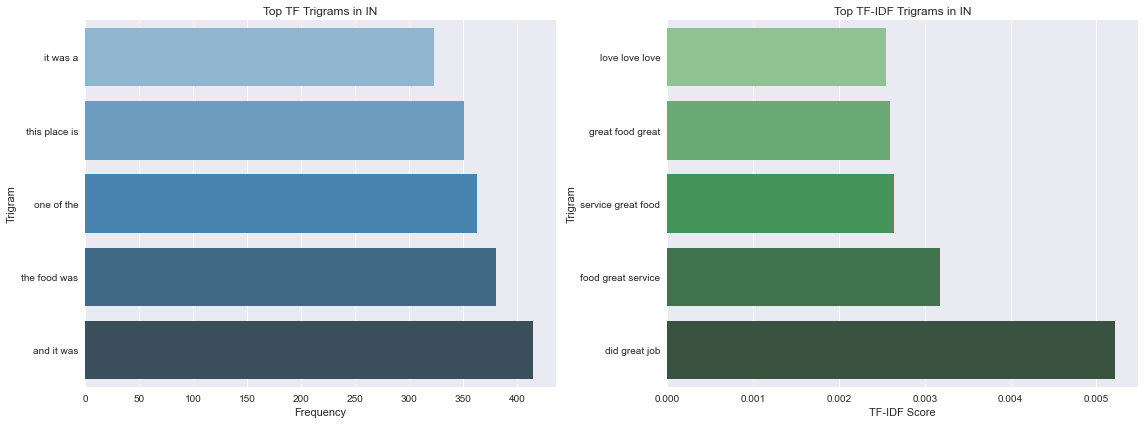


 Showing plots for state: LA


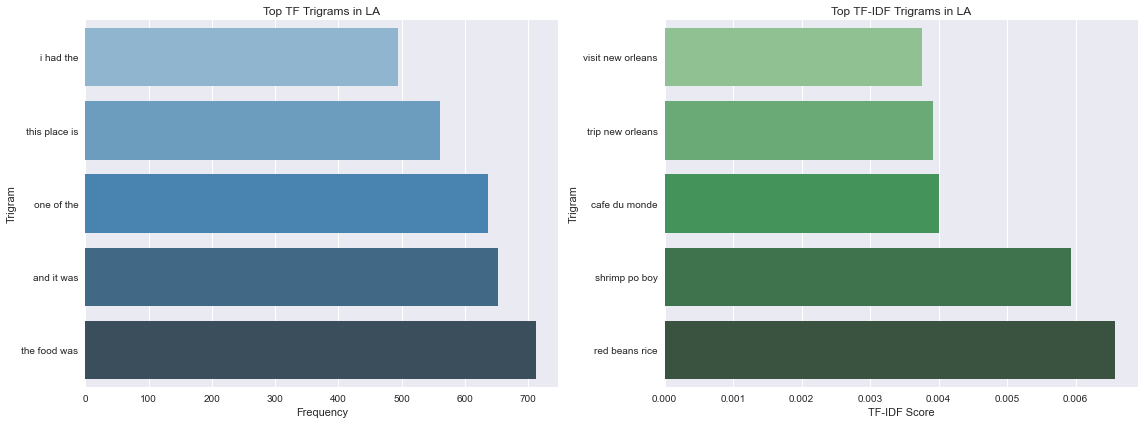


 Showing plots for state: MO


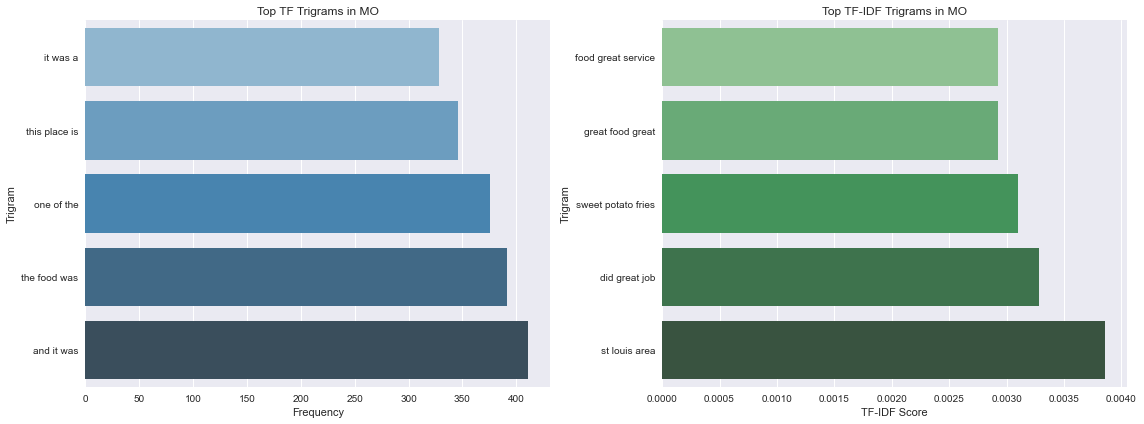


 Showing plots for state: NJ


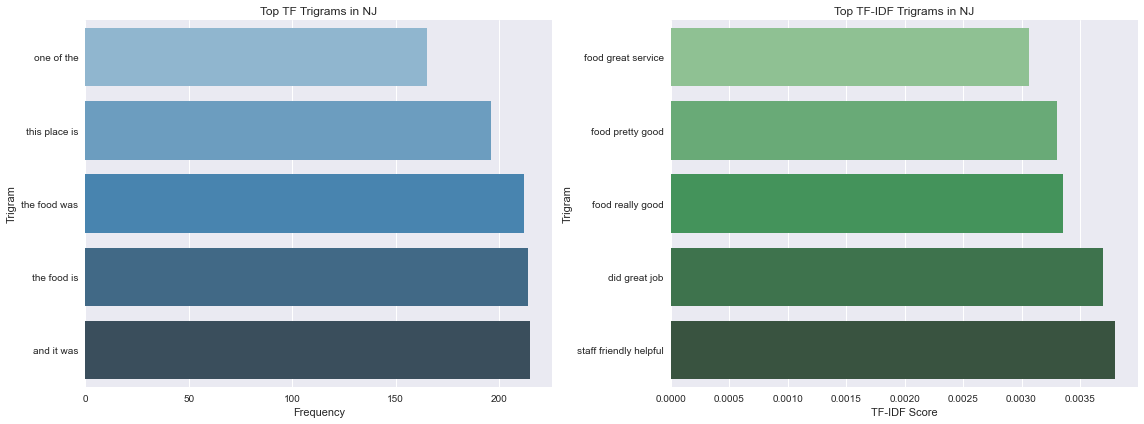


 Showing plots for state: NV


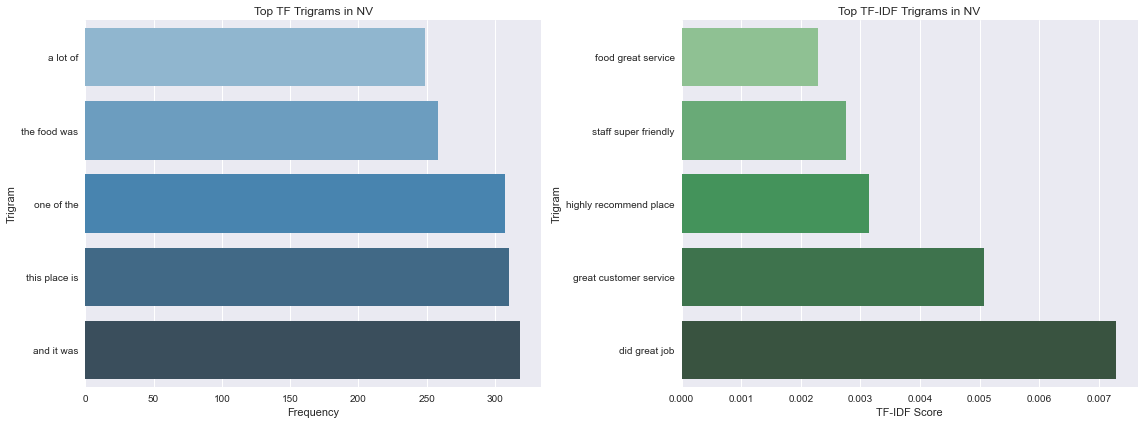


 Showing plots for state: PA


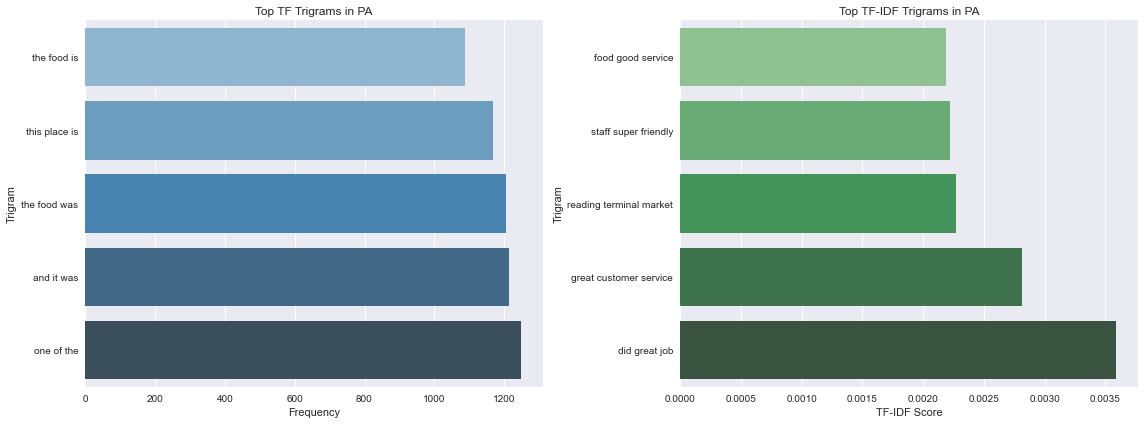


 Showing plots for state: SD


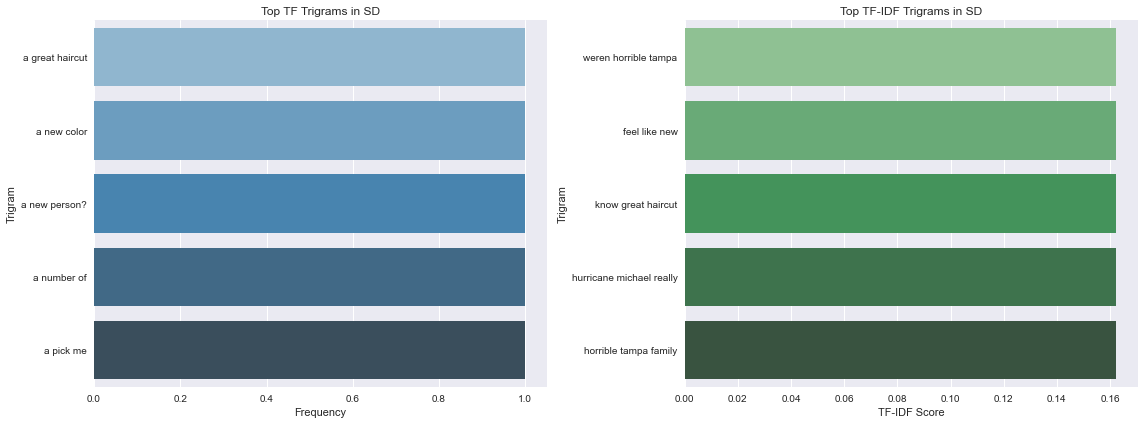


 Showing plots for state: TN


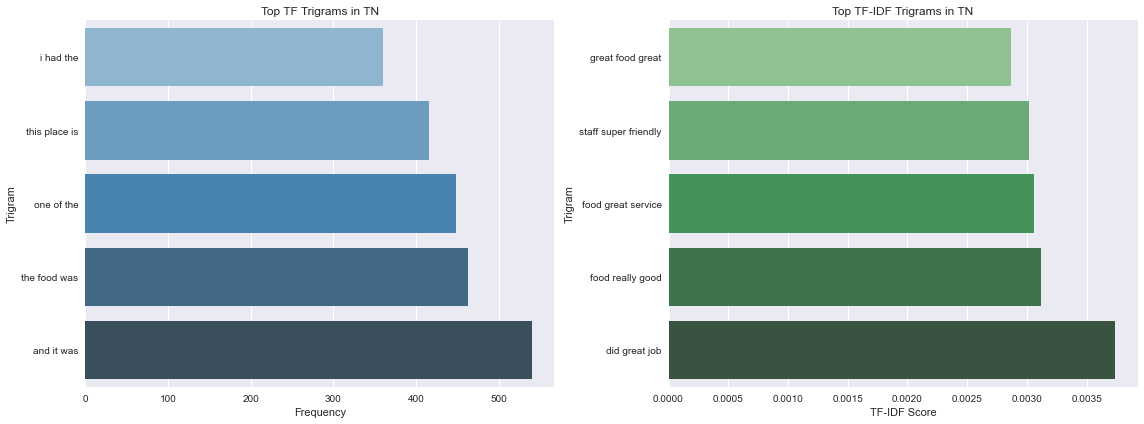


 Showing plots for state: TX


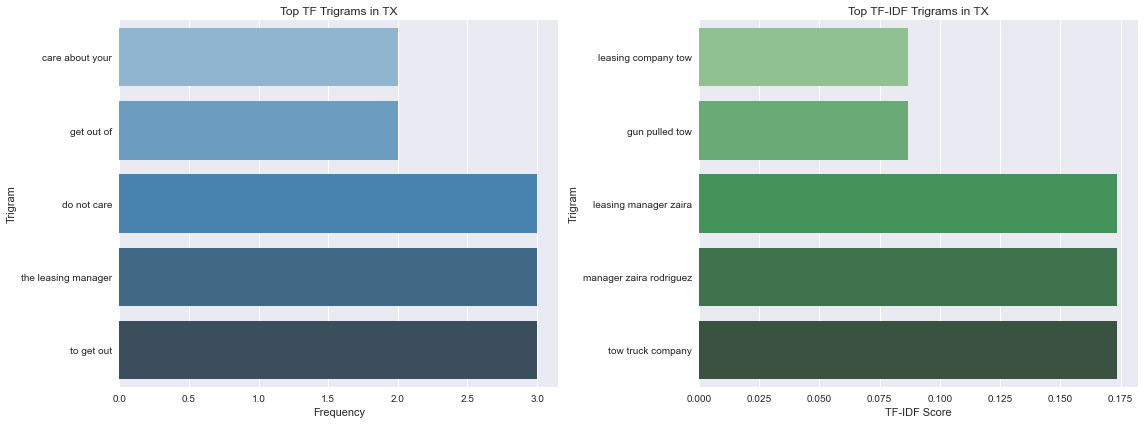


 Showing plots for state: UT


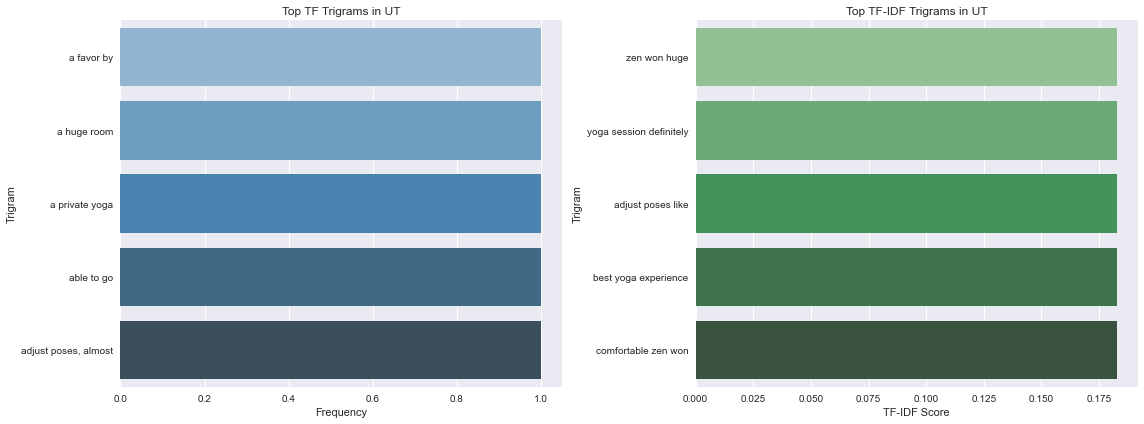

In [139]:
# Run for all states for what's often said (TF) and what's uniquely said (TD-IDF)
loop_and_plot_all_trigrams(
    tf_df=top_trigrams_per_state,
    tfidf_df=top_tfidf_trigrams_state,
    group_col='state'
)

---
### Create a dictionary and inspect the corpus for targeted insights 
---

What if your manager wants to inquire if "did any customer complain about our last live show singer?" you can create a dictionary with the name of the live show singer and then inspect the corpus with it. You can also create dictionaries with phrases and inspect the corpus with it. Below, we shall inspect the corpus for words like quality, value, expect, complain, loyalty, satisfied and service. We will do this using inverse document frequency. 


TF-IDF Scores for Dictionary Terms:
service      25677.690123
quality       4609.844588
expect        2047.404688
value          947.051192
satisfied      878.546628
complain       571.260140
loyalty         77.071180
dtype: float64


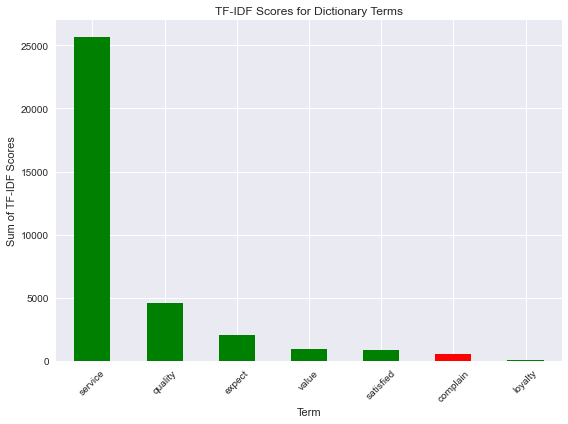

In [158]:
# --- Dictionary-Based TF-IDF Analysis ---

# Step 1: Define a custom vocabulary (dictionary of important terms to focus on)
dictionary = ['quality', 'value', 'expect', 'complain', 'loyalty', 'satisfied', 'service']

# Step 2: Initialize TfidfVectorizer with your dictionary
# Only the words in this list will be considered when calculating TF-IDF
tfidf_dict = TfidfVectorizer(vocabulary=dictionary)

# Step 3: Fit the TF-IDF model on the entire corpus (df['text']) and transform the text into a matrix
# This returns a sparse matrix where each row = review, each column = a term from the dictionary
tfidf_dict_matrix = tfidf_dict.fit_transform(df['text'])

# Step 4: Convert the sparse matrix into a dense DataFrame for easier analysis
# Each column corresponds to a word in the dictionary
tfidf_dict_df = pd.DataFrame(tfidf_dict_matrix.toarray(), columns=dictionary)

# Step 5: Summarize the importance of each word by summing its TF-IDF scores across all documents
# Higher scores mean the word is more important (frequent and distinctive) in the overall corpus
tfidf_dict_summary = tfidf_dict_df.sum().sort_values(ascending=False)

# Step 6: Print the TF-IDF scores for each dictionary term
print("\nTF-IDF Scores for Dictionary Terms:")
print(tfidf_dict_summary)

# Step 7: Visualize the results as a bar chart
plt.figure(figsize=(8, 6))

# Color the 'complain' bar red (to highlight negative sentiment), all others green
tfidf_dict_summary.plot(
    kind='bar',
    color=['red' if x in ['complain'] else 'green' for x in tfidf_dict_summary.index]
)

plt.title('TF-IDF Scores for Dictionary Terms')
plt.xlabel('Term')
plt.ylabel('Sum of TF-IDF Scores')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
#### Conclusion
---

This analysis surfaced clear linguistic patterns in customer reviews using TF-IDF and bigram/trigram techniques.

### Key Findings:
- High-TF-IDF phrases like “excellent service” and “delicious food” were prominent in top-rated businesses.
- Common complaints centered around “long wait time” and “poor service,” especially in categories like restaurants and salons.
- State-level variations showed that certain states valued friendliness more, while others emphasized efficiency or cleanliness.

### Business Implications:
- Use top positive trigrams in marketing messaging regionally (e.g., “fast service” in Texas, “friendly staff” in California).
- Prioritize operational improvements where negative sentiment is concentrated by category and location.
- Continuously monitor TF-IDF shifts to capture emerging customer priorities.

This framework turns unstructured feedback into strategic guidance for brand, product, and customer experience teams.
